#วิเคราะห์ข้อมูลที่ดาวน์โหลดมา

In [ ]:
# ==============================================================================================
# COPY AS CELL 1
# ==============================================================================================
# CELL 01 — SETUP, DRIVE, IMPORTS, CONFIGURATION
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 240)

STATION_WMO = '48426'
STATION_NAME = 'Lop Buri'
LOCAL_TZ = 'Asia/Bangkok'

BASE_DIR = Path('/content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426')
INPUT_PROCESSED_DIR = BASE_DIR / 'processed'

ANALYSIS_START_DATE = '2024-01-01'
ANALYSIS_END_DATE   = '2024-12-31'

CORE_SYNOP_HOURS_LOCAL = [1,4,7,10,13,16,19,22]
STANDARDIZED_DAY_MIN_SLOTS = 6
VARIABLE_MIN_VALID_SLOTS = 6
CALM_THRESHOLD_MS = 0.5
VISIBILITY_INPUT_UNIT = 'm'
FIG_DPI = 300
RAIN_MULTIPATH_TOLERANCE_MM = 0.1

ANALYSIS_DIR = BASE_DIR / f'meteorological_analysis_{ANALYSIS_START_DATE}_{ANALYSIS_END_DATE}'
FIG_DIR = ANALYSIS_DIR / 'figures'
TABLE_DIR = ANALYSIS_DIR / 'tables'
QA_DIR = ANALYSIS_DIR / 'qa'
for d in [ANALYSIS_DIR, FIG_DIR, TABLE_DIR, QA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# The corrected wind module writes some CSVs to PROCESSED_DIR.
# Point it to this notebook's table folder, not to the downloader's input folder.
PROCESSED_DIR = TABLE_DIR

print('Base:', BASE_DIR)
print('Analysis:', ANALYSIS_DIR)
print('Period:', ANALYSIS_START_DATE, 'to', ANALYSIS_END_DATE)
print('✅ Cell 01 completed.')

Mounted at /content/drive
Base: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426
Analysis: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31
Period: 2024-01-01 to 2024-12-31
✅ Cell 01 completed.


In [ ]:

# ==============================================================================================
# COPY AS CELL 2
# ==============================================================================================
# CELL 02 — DISCOVER AND LOAD DOWNLOADED DATA

def load_many(paths):
    frames=[]
    for p in paths:
        try:
            df=pd.read_csv(p)
            df['source_file']=str(p)
            frames.append(df)
        except Exception as exc:
            print('WARNING:', p, repr(exc))
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

subdaily_files=sorted(INPUT_PROCESSED_DIR.glob(f"{STATION_WMO}_{STATION_NAME.replace(' ','')}_subdaily_harmonized_*.csv"))
daily_files=sorted(INPUT_PROCESSED_DIR.glob(f"{STATION_WMO}_{STATION_NAME.replace(' ','')}_daily_meteorology_*.csv"))
precip_files=sorted(INPUT_PROCESSED_DIR.glob(f"{STATION_WMO}_{STATION_NAME.replace(' ','')}_precipitation_intervals_*.csv"))

if not subdaily_files:
    raise RuntimeError('No harmonized subdaily file found. Run the SYNOP downloader first.')

subdaily=load_many(subdaily_files)

if 'datetime_utc' in subdaily.columns:
    subdaily['datetime_utc']=pd.to_datetime(subdaily['datetime_utc'], utc=True, errors='coerce')
if 'datetime_local' in subdaily.columns:
    subdaily['datetime_local']=pd.to_datetime(subdaily['datetime_local'], utc=True, errors='coerce').dt.tz_convert(LOCAL_TZ)
elif 'datetime_utc' in subdaily.columns:
    subdaily['datetime_local']=subdaily['datetime_utc'].dt.tz_convert(LOCAL_TZ)
else:
    raise RuntimeError('No datetime_local or datetime_utc field in subdaily data.')

subdaily['date_local']=subdaily['datetime_local'].dt.tz_localize(None).dt.normalize()
subdaily['hour_local']=subdaily['datetime_local'].dt.hour
start=pd.Timestamp(ANALYSIS_START_DATE)
end=pd.Timestamp(ANALYSIS_END_DATE)
subdaily=subdaily[subdaily['date_local'].between(start,end)].copy()
keys=[c for c in ['station','datetime_utc'] if c in subdaily.columns] or ['datetime_local']
subdaily=subdaily.drop_duplicates(keys, keep='last').sort_values('datetime_local').reset_index(drop=True)

precip_intervals=load_many(precip_files)
for c in ['accumulation_start_utc','accumulation_end_utc']:
    if c in precip_intervals.columns:
        precip_intervals[c]=pd.to_datetime(precip_intervals[c], utc=True, errors='coerce')
for c in ['accumulation_start_local','accumulation_end_local']:
    if c in precip_intervals.columns:
        precip_intervals[c]=pd.to_datetime(precip_intervals[c], utc=True, errors='coerce').dt.tz_convert(LOCAL_TZ)

print('Subdaily files:', len(subdaily_files))
print('Subdaily rows after crop/dedup:', len(subdaily))
print('Local span:', subdaily['datetime_local'].min(), 'to', subdaily['datetime_local'].max())
print('Precipitation interval files:', len(precip_files), 'rows:', len(precip_intervals))
print('✅ Cell 02 completed.')

Subdaily files: 2
Subdaily rows after crop/dedup: 6639
Local span: 2024-01-01 01:00:00+07:00 to 2024-12-31 23:00:00+07:00
Precipitation interval files: 2 rows: 1751
✅ Cell 02 completed.


In [ ]:



# ==============================================================================================
# COPY AS CELL 3
# ==============================================================================================
# CELL 03 — INPUT SCHEMA, RANGE, AND REPORTING-CADENCE AUDIT
expected=['t2m','dpt2m','rh_raw_pct','rh_calculated_pct','rh_used_pct','rel_hum',
          'wind_speed_ms','wind_direction_deg','u_ms','v_ms','press','slp','Nt','visibility']

schema=pd.DataFrame({'field':expected,'present':[x in subdaily.columns for x in expected]})
schema.to_csv(QA_DIR/'01_input_schema_audit.csv', index=False, encoding='utf-8-sig')

ranges=[]
for c in expected:
    if c not in subdaily.columns: continue
    x=pd.to_numeric(subdaily[c], errors='coerce').dropna()
    ranges.append({'field':c,'n_valid':len(x),'valid_fraction':len(x)/len(subdaily) if len(subdaily) else np.nan,
                   'min':x.min() if len(x) else np.nan,'median':x.median() if len(x) else np.nan,
                   'p90':x.quantile(.9) if len(x) else np.nan,'max':x.max() if len(x) else np.nan})
range_audit=pd.DataFrame(ranges)
range_audit.to_csv(QA_DIR/'02_input_range_audit.csv', index=False, encoding='utf-8-sig')

cad=[]
for (y,m),g in subdaily.groupby([subdaily['date_local'].dt.year,subdaily['date_local'].dt.month], sort=True):
    counts=g.groupby('date_local')['hour_local'].nunique()
    cad.append({'year':int(y),'month':int(m),'n_days':len(counts),
                'median_unique_hours_per_day':counts.median(),'q75_unique_hours_per_day':counts.quantile(.75),
                'max_unique_hours_per_day':counts.max()})
cadence_audit=pd.DataFrame(cad)
cadence_audit.to_csv(QA_DIR/'03_reporting_cadence_audit.csv', index=False, encoding='utf-8-sig')

print('SCHEMA')
print(schema.to_string(index=False))
print('\nRANGES')
print(range_audit.round(3).to_string(index=False))
print('\nCADENCE')
print(cadence_audit.round(2).to_string(index=False))
print('✅ Cell 03 completed.')


# ==============================================================================================
# COPY AS CELL 4
# ==============================================================================================
# CELL 04 — STANDARDIZE 3-HOURLY METEOROLOGY + DERIVED VARIABLES
met_core=subdaily[subdaily['hour_local'].isin(CORE_SYNOP_HOURS_LOCAL)].copy()
met_core=met_core.drop_duplicates(['date_local','hour_local'], keep='last').sort_values('datetime_local')

qa_rows=[]
for d,g in met_core.groupby('date_local', sort=True):
    n=g['hour_local'].nunique()
    qa_rows.append({'date_local':pd.Timestamp(d),'n_standardized_slots':n,
                    'standardized_slot_fraction':n/8,
                    'standardized_day_QA_pass':bool(n>=STANDARDIZED_DAY_MIN_SLOTS)})
standard_day_qa=pd.DataFrame(qa_rows)
met_std=met_core.merge(standard_day_qa,on='date_local',how='left',validate='many_to_one')
met_std=met_std[met_std['standardized_day_QA_pass']==True].copy()
met_std['day_weight']=1.0/met_std['n_standardized_slots']
met_std['month']=met_std['date_local'].dt.month
met_std['year']=met_std['date_local'].dt.year
met_std['season']=np.where(met_std['month'].isin([11,12,1,2,3,4]),'DRY','WET')
met_std['season_year']=met_std['year']+met_std['month'].isin([11,12]).astype(int)

for c in ['t2m','dpt2m','rh_raw_pct','rh_calculated_pct','rh_used_pct','rel_hum','wind_speed_ms','wind_direction_deg','u_ms','v_ms','press','slp','Nt','visibility']:
    if c in met_std.columns:
        met_std[c]=pd.to_numeric(met_std[c], errors='coerce')

if 'rh_used_pct' not in met_std.columns:
    met_std['rh_used_pct']=met_std['rel_hum'] if 'rel_hum' in met_std.columns else np.nan

T=met_std['t2m'] if 't2m' in met_std.columns else pd.Series(np.nan,index=met_std.index)
Td=met_std['dpt2m'] if 'dpt2m' in met_std.columns else pd.Series(np.nan,index=met_std.index)
RH=met_std['rh_used_pct']
met_std['dewpoint_depression_c']=T-Td
es=0.61094*np.exp(17.625*T/(T+243.04))
ea_td=0.61094*np.exp(17.625*Td/(Td+243.04))
ea_rh=es*RH/100.0
met_std['actual_vapor_pressure_kpa']=ea_td.where(ea_td.notna(),ea_rh)
met_std['vpd_kpa']=(es-met_std['actual_vapor_pressure_kpa']).clip(lower=0)
press=met_std['press'] if 'press' in met_std.columns else pd.Series(np.nan,index=met_std.index)
slp=met_std['slp'] if 'slp' in met_std.columns else pd.Series(np.nan,index=met_std.index)
p_for_q=press.where(press.notna(),slp)
e_hpa=met_std['actual_vapor_pressure_kpa']*10.0
met_std['specific_humidity_gkg']=1000*0.622*e_hpa/(p_for_q-0.378*e_hpa)

Nt=met_std['Nt'] if 'Nt' in met_std.columns else pd.Series(np.nan,index=met_std.index)
met_std['cloud_okta']=Nt.where(Nt.between(0,8,inclusive='both'))
met_std['cloud_obscured_code9']=(Nt==9)
vis=met_std['visibility'] if 'visibility' in met_std.columns else pd.Series(np.nan,index=met_std.index)
met_std['visibility_km']=vis/1000.0 if VISIBILITY_INPUT_UNIT.lower()=='m' else vis

met_std.to_csv(TABLE_DIR/'standardized_3hourly_meteorology_with_derived_variables.csv',index=False,encoding='utf-8-sig')
standard_day_qa.to_csv(QA_DIR/'04_standardized_day_QA.csv',index=False,encoding='utf-8-sig')

print('Standardized rows:',len(met_std))
print('Standardized QA-pass days:',met_std['date_local'].nunique())
print('✅ Cell 04 completed.')


# ==============================================================================================
# COPY AS CELL 5
# ==============================================================================================
# CELL 05 — VARIABLE-SPECIFIC DAILY QA + DAILY METEOROLOGICAL MASTER

def resdir(u,v):
    if not np.isfinite(u) or not np.isfinite(v) or (u==0 and v==0): return np.nan
    return (np.degrees(np.arctan2(-u,-v))+360)%360

varcols={'temperature':'t2m','dewpoint':'dpt2m','rh':'rh_used_pct','wind':'wind_speed_ms',
         'station_pressure':'press','slp':'slp','cloud':'cloud_okta','visibility':'visibility_km'}
rows=[]
for d,g in met_std.groupby('date_local',sort=True):
    r={'date_local':pd.Timestamp(d),'year':int(pd.Timestamp(d).year),'month':int(pd.Timestamp(d).month),
       'season':g['season'].iloc[0],'season_year':int(g['season_year'].iloc[0]),
       'n_standardized_slots':int(g['hour_local'].nunique())}
    for label,c in varcols.items():
        n=int(g[c].notna().sum()) if c in g.columns else 0
        r[f'{label}_n_valid']=n
        r[f'{label}_QA_pass']=bool(n>=VARIABLE_MIN_VALID_SLOTS)
    if r['temperature_QA_pass']:
        x=g['t2m'].dropna(); r['temperature_mean_c']=x.mean(); r['temperature_min_observed_3h_c']=x.min(); r['temperature_max_observed_3h_c']=x.max(); r['dtr_observed_3h_c']=x.max()-x.min()
    else:
        r['temperature_mean_c']=r['temperature_min_observed_3h_c']=r['temperature_max_observed_3h_c']=r['dtr_observed_3h_c']=np.nan
    for src,out,flag in [('dpt2m','dewpoint_mean_c','dewpoint_QA_pass'),('rh_used_pct','rh_mean_pct','rh_QA_pass'),
                         ('dewpoint_depression_c','dewpoint_depression_mean_c','dewpoint_QA_pass'),('vpd_kpa','vpd_mean_kpa','dewpoint_QA_pass'),
                         ('specific_humidity_gkg','specific_humidity_mean_gkg','dewpoint_QA_pass')]:
        r[out]=g[src].mean() if src in g.columns and r[flag] else np.nan
    if r['wind_QA_pass']:
        w=g[g['wind_speed_ms'].notna() & g['u_ms'].notna() & g['v_ms'].notna()]
        ws=w['wind_speed_ms'].mean(); u=w['u_ms'].mean(); v=w['v_ms'].mean(); vr=np.sqrt(u*u+v*v)
        r.update({'wind_speed_scalar_mean_ms':ws,'u_mean_ms':u,'v_mean_ms':v,'wind_speed_resultant_ms':vr,
                  'wind_direction_resultant_deg':resdir(u,v),'wind_persistence_ratio':vr/ws if ws>0 else np.nan})
    else:
        for c in ['wind_speed_scalar_mean_ms','u_mean_ms','v_mean_ms','wind_speed_resultant_ms','wind_direction_resultant_deg','wind_persistence_ratio']: r[c]=np.nan
    r['station_pressure_mean_hpa']=g['press'].mean() if 'press' in g.columns and r['station_pressure_QA_pass'] else np.nan
    r['slp_mean_hpa']=g['slp'].mean() if 'slp' in g.columns and r['slp_QA_pass'] else np.nan
    r['cloud_mean_okta']=g['cloud_okta'].mean() if r['cloud_QA_pass'] else np.nan
    r['cloud_obscured_reports']=int(g['cloud_obscured_code9'].sum())
    r['visibility_median_km']=g['visibility_km'].median() if r['visibility_QA_pass'] else np.nan
    r['visibility_p10_km']=g['visibility_km'].quantile(.1) if r['visibility_QA_pass'] else np.nan
    rows.append(r)

daily_met=pd.DataFrame(rows)
daily_met.to_csv(TABLE_DIR/'daily_standardized_meteorology_master.csv',index=False,encoding='utf-8-sig')
flags=[c for c in daily_met.columns if c.endswith('_QA_pass')]
qa_summary=pd.DataFrame({'QA_flag':flags,'n_pass_days':[int(daily_met[c].sum()) for c in flags],'pass_fraction':[daily_met[c].mean() for c in flags]})
qa_summary.to_csv(QA_DIR/'05_variable_specific_daily_QA_summary.csv',index=False,encoding='utf-8-sig')
print(qa_summary.round(3).to_string(index=False))
print('Daily master rows:',len(daily_met))
print('✅ Cell 05 completed.')

SCHEMA
             field  present
               t2m     True
             dpt2m     True
        rh_raw_pct    False
 rh_calculated_pct     True
       rh_used_pct     True
           rel_hum     True
     wind_speed_ms     True
wind_direction_deg     True
              u_ms     True
              v_ms     True
             press     True
               slp     True
                Nt     True
        visibility     True

RANGES
             field  n_valid  valid_fraction      min   median       p90       max
               t2m     6639           1.000   18.300   28.600    33.700    41.200
             dpt2m     5732           0.863   11.700   24.600    26.300    28.400
 rh_calculated_pct     5732           0.863   23.868   71.347    88.884    98.814
       rh_used_pct     5732           0.863   23.900   71.350    88.900    98.800
           rel_hum     5732           0.863   23.900   71.350    88.900    98.800
     wind_speed_ms     6639           1.000    0.000    1.029     3.087  

## วิเคราะห์ลม

All-available wind observations: 6639
Core-hour observations before daily QA: 2927
PRIMARY standardized observations: 2927
Standardized QA-pass days: 366
Core Thailand-local hours: [1, 4, 7, 10, 13, 16, 19, 22]
Minimum daily standardized slots: 6 / 8
Calm threshold: 0.5 m/s

REPORTING CADENCE / STANDARDIZATION AUDIT
 year  month  n_all_available_observations  n_standardized_observations  n_standardized_QA_pass_days  expected_standardized_observations_if_complete  standardized_observation_coverage
 2024      1                           248                          248                           31                                             248                              1.000
 2024      2                           232                          232                           29                                             232                              1.000
 2024      3                           248                          248                           31                              

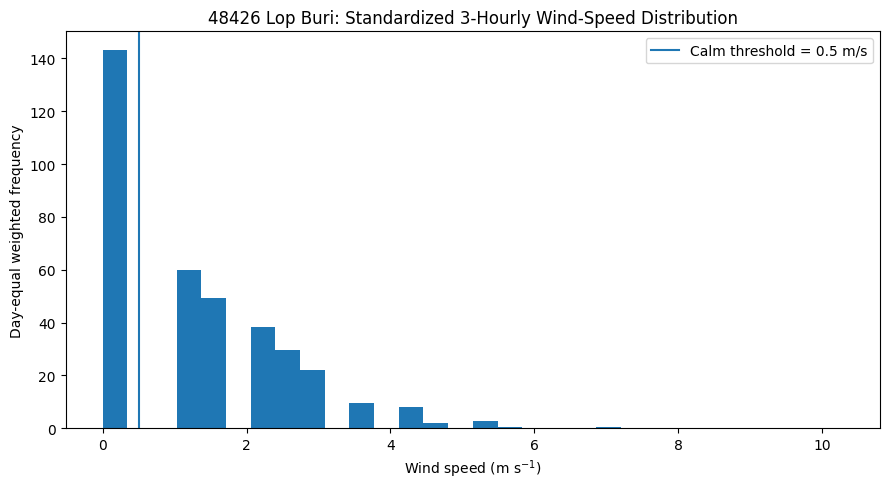


Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig06_STANDARDIZED_wind_speed_distribution.png

✅ Cell 19 completed.


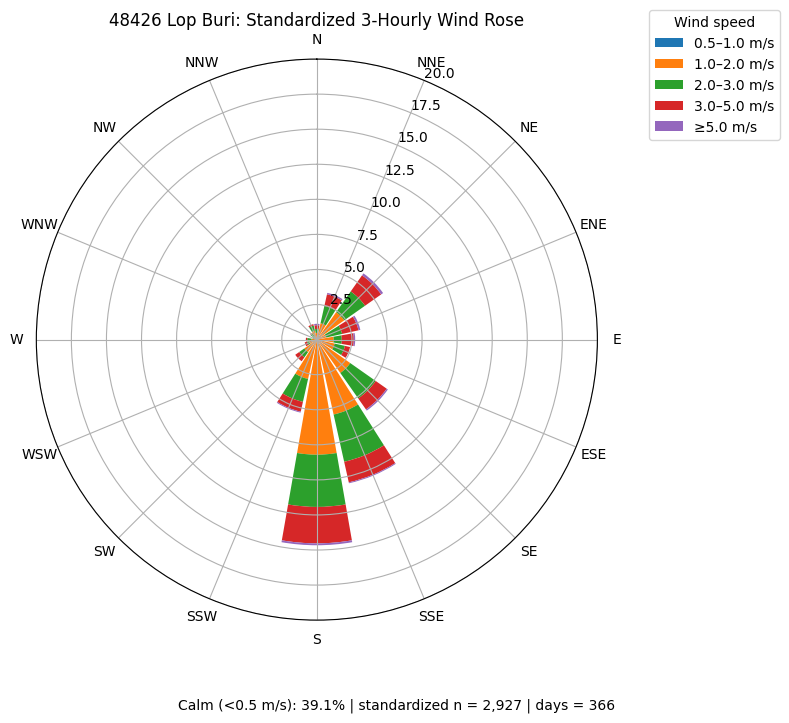

Common standardized radial maximum: 20.0
Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig07_STANDARDIZED_overall_16_sector_wind_rose.png

✅ Cell 20 completed.


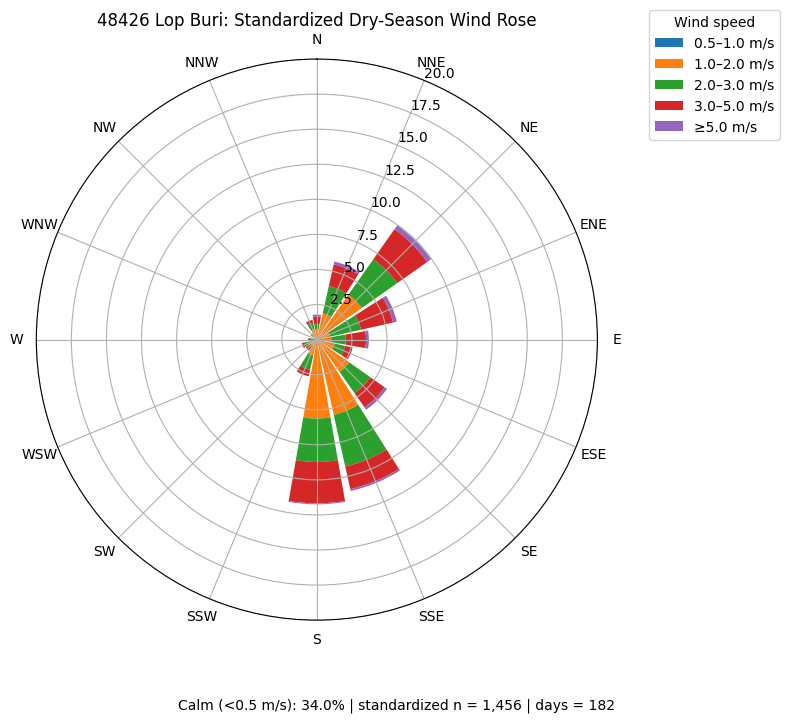

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig08_STANDARDIZED_dry_season_wind_rose.png


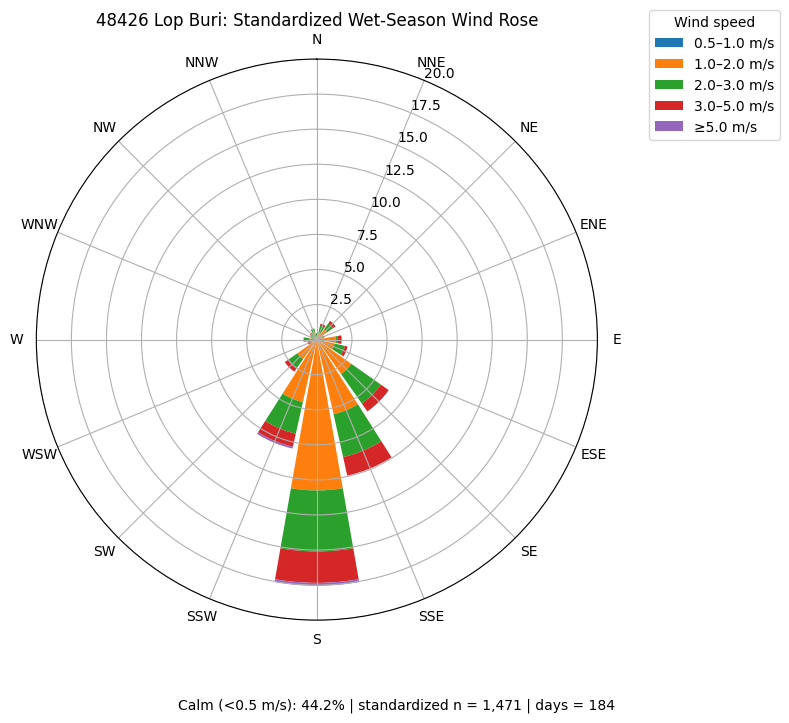

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig09_STANDARDIZED_wet_season_wind_rose.png

STANDARDIZED SEASONAL WIND-ROSE SUMMARY
season  n_standardized_observations  n_days  calm_percent_day_weighted  radial_max_percent
   DRY                         1456     182                      34.00                20.0
   WET                         1471     184                      44.16                20.0

✅ Cell 21 completed.

STANDARDIZED 8-SECTOR WIND STATISTICS
sector  n_observations  day_weight_sum  percent_of_all_valid_day_weighted  percent_of_noncalm_day_weighted  weighted_mean_speed_ms  weighted_median_speed_ms  weighted_p75_speed_ms  weighted_p90_speed_ms  max_speed_ms  sector_vector_resultant_speed_ms  sector_vector_direction_deg  sector_persistence_ratio
     N              88          11.000                              3.005                            4.936                   2.233                     

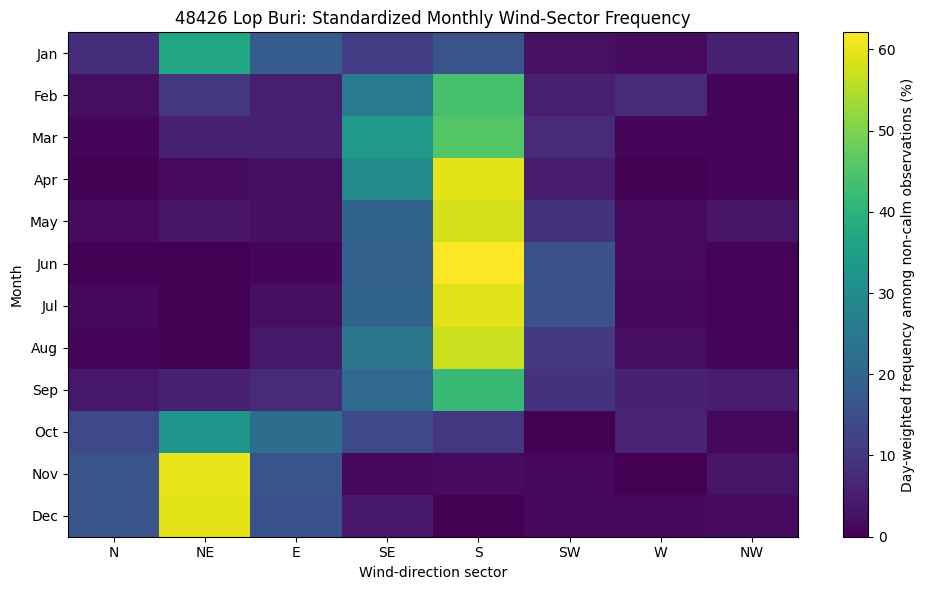


STANDARDIZED MONTHLY CALM-WIND STATISTICS
 month  n_standardized_observations  n_days  calm_percent_day_weighted
     1                          248      31                      55.24
     2                          232      29                      42.24
     3                          248      31                      24.60
     4                          240      30                      11.25
     5                          248      31                      37.50
     6                          240      30                      24.17
     7                          247      31                      36.69
     8                          248      31                      49.19
     9                          240      30                      49.17
    10                          248      31                      67.74
    11                          240      30                      35.42
    12                          248      31                      35.08

Saved: /content/drive/MyDrive/Sar

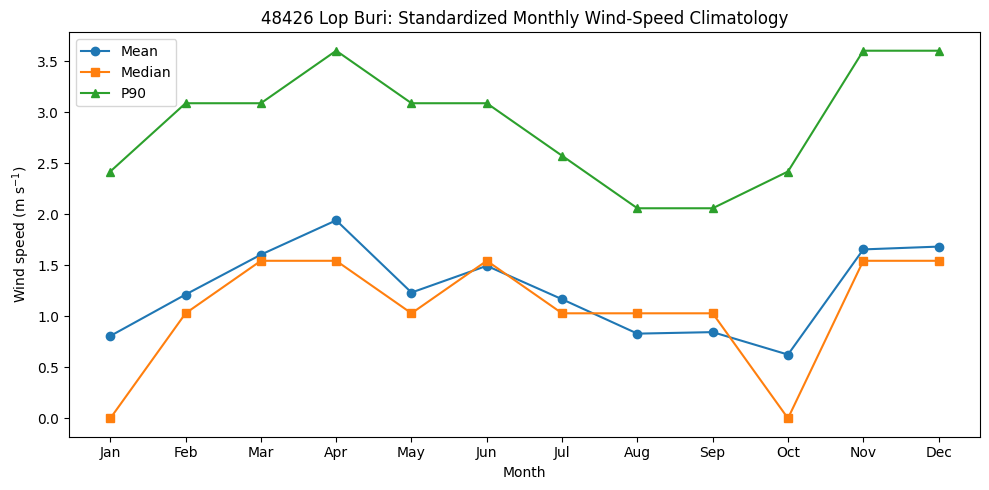

 month  n_standardized_observations  n_days  weighted_mean_speed_ms  weighted_median_speed_ms  weighted_p75_speed_ms  weighted_p90_speed_ms  calm_percent_day_weighted
     1                          248      31                   0.807                     0.000                  1.543                  2.418                     55.242
     2                          232      29                   1.213                     1.029                  2.058                  3.087                     42.241
     3                          248      31                   1.603                     1.543                  2.572                  3.087                     24.597
     4                          240      30                   1.940                     1.543                  2.572                  3.601                     11.250
     5                          248      31                   1.232                     1.029                  2.058                  3.087                     37.50

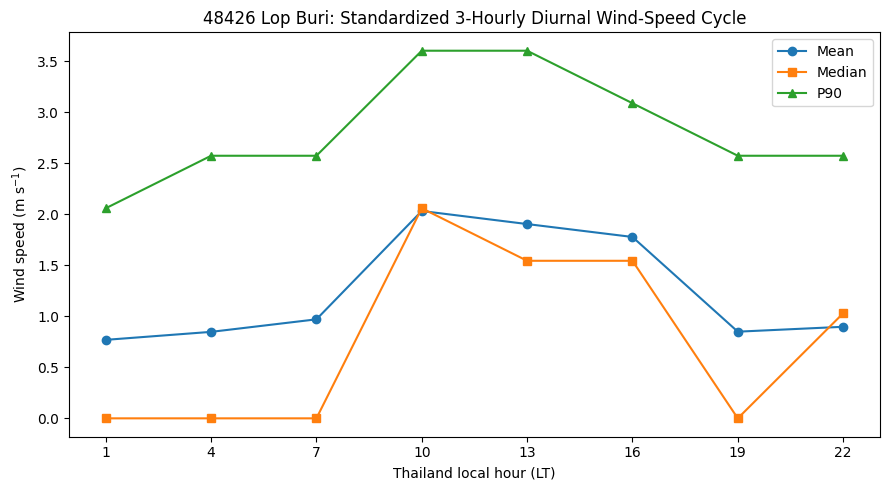

 hour_local  n_observations  n_days  mean_speed_ms  median_speed_ms  p75_speed_ms  p90_speed_ms  calm_percent
          1             366     366          0.769            0.000         1.543         2.058        54.098
          4             365     365          0.847            0.000         1.543         2.572        57.260
          7             366     366          0.970            0.000         1.543         2.572        51.639
         10             366     366          2.031            2.058         3.087         3.601        13.388
         13             366     366          1.903            1.543         2.572         3.601        14.481
         16             366     366          1.777            1.543         2.572         3.087        19.399
         19             366     366          0.849            0.000         1.543         2.572        53.005
         22             366     366          0.897            1.029         1.543         2.572        49.727

Saved: /c

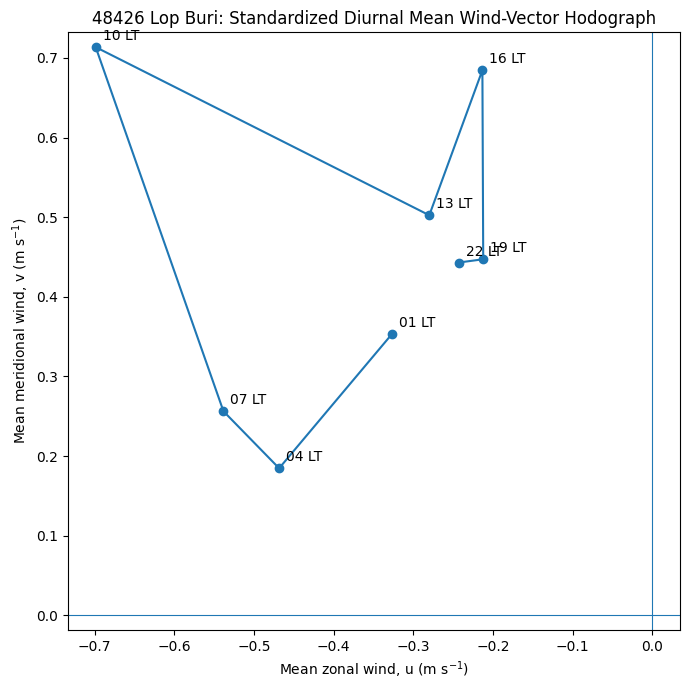

 hour_local  n_observations  n_days  u_mean_ms  v_mean_ms  scalar_mean_ms  resultant_speed_ms  resultant_direction_deg  persistence_ratio
          1             366     366     -0.327      0.354           0.769               0.481                  137.272              0.626
          4             365     365     -0.468      0.185           0.847               0.504                  111.516              0.594
          7             366     366     -0.538      0.256           0.970               0.596                  115.455              0.615
         10             366     366     -0.699      0.714           2.031               0.999                  135.598              0.492
         13             366     366     -0.280      0.502           1.903               0.575                  150.877              0.302
         16             366     366     -0.213      0.685           1.777               0.717                  162.702              0.404
         19             366     36

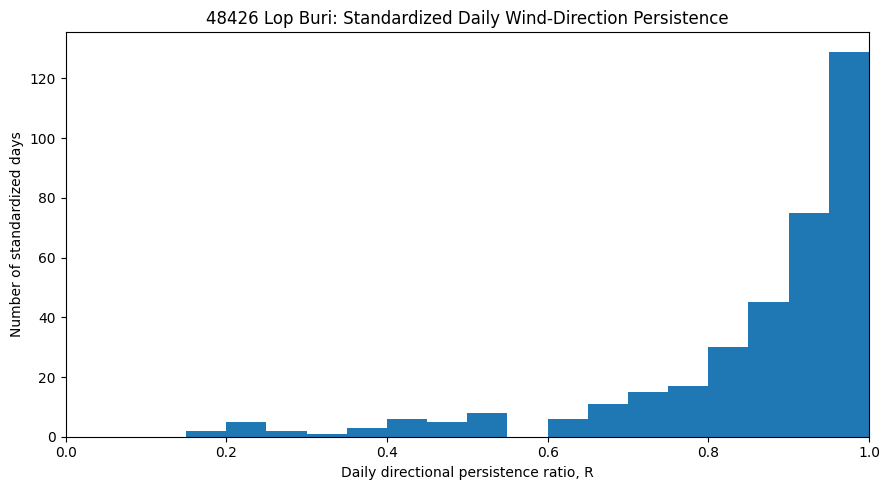

                     dataset  n_days  mean_R  std_R  p10_R  p25_R  median_R  p75_R  p90_R
STANDARDIZED_3HOURLY_PRIMARY     360   0.856  0.172  0.639  0.821     0.921  0.968   0.99

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig14_STANDARDIZED_daily_wind_persistence_distribution.png

✅ Cell 27 completed.

STANDARDIZED DRY vs WET WIND-REGIME SUMMARY
season  n_standardized_observations  n_days  calm_percent_day_weighted  weighted_mean_speed_ms  weighted_median_speed_ms  weighted_p90_speed_ms  vector_resultant_speed_ms  vector_resultant_direction_deg  vector_persistence_ratio  median_daily_persistence_R
   DRY                         1456     182                     33.997                   1.483                     1.543                  3.087                      0.661                         108.542                     0.445                       0.925
   WET                         1471     184            

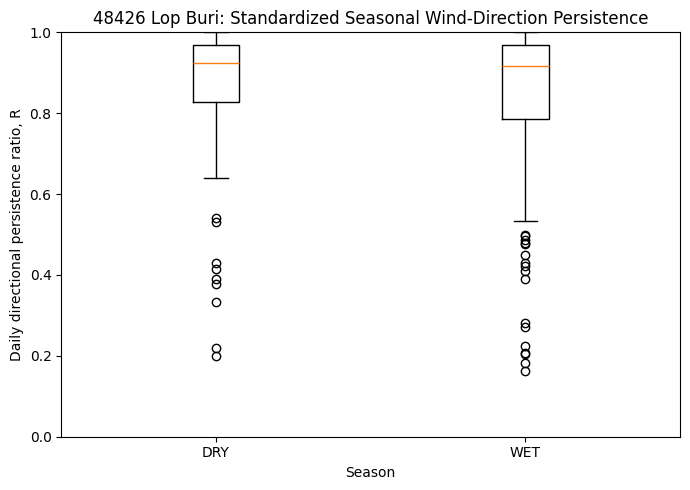


Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig15_STANDARDIZED_seasonal_wind_persistence.png

✅ Cell 28 completed.


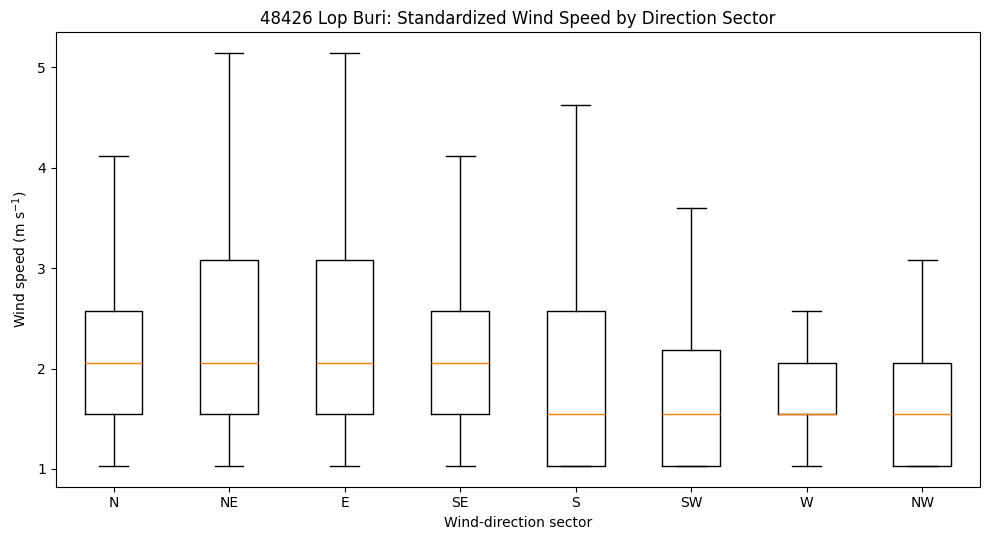

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/meteorological_analysis_2024-01-01_2024-12-31/figures/Fig16_STANDARDIZED_wind_speed_by_direction_sector.png

✅ Cell 29 completed.


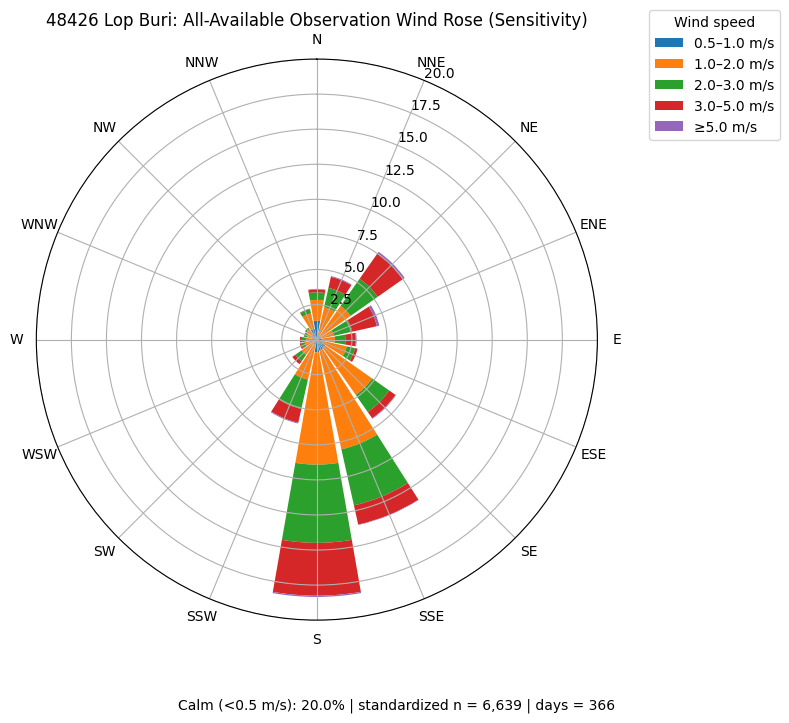


ALL-AVAILABLE vs STANDARDIZED SUMMARY
                     dataset  n_observations  n_days  calm_percent  mean_speed_ms  vector_resultant_speed_ms  vector_resultant_direction_deg  vector_persistence_ratio
   ALL_AVAILABLE_SENSITIVITY            6639     366        19.958          1.490                      0.626                         139.931                     0.420
STANDARDIZED_3HOURLY_PRIMARY            2927     366        39.105          1.255                      0.583                         140.291                     0.464

SECTOR-FREQUENCY SENSITIVITY
sector  all_available_percent_noncalm  standardized_percent_noncalm  standardized_minus_all_percentage_points
     N                          8.148                         4.936                                    -3.213
    NE                         16.805                        16.545                                    -0.260
     E                          6.869                         7.515                                 

In [ ]:
# ==============================================================================================
# COPY AS CELL 6
# ==============================================================================================
# =====================================================================
# CELL 6 — WIND MODULE: PREPARE STANDARDIZED WIND CLIMATOLOGY DATA
#
# PRIMARY CLIMATOLOGY:
#   Use only the common 3-hourly SYNOP schedule in Thailand local time:
#       01, 04, 07, 10, 13, 16, 19, 22 LT
#
# WHY:
#   Reporting cadence changed during 2024 (about 8/day early in the year
#   and near-hourly later). Using every available observation would
#   over-weight months with hourly reporting.
#
# PRIMARY RULE:
#   - retain the 8 common local-time slots
#   - require >= 75% of the 8 slots per day (>= 6 slots)
#   - give every retained day equal total statistical weight
#
# SENSITIVITY:
#   `wind_all` preserves every available SYNOP wind observation.
#
# No PM2.5 data are used in Cells 18–30.
# =====================================================================

# ---------------------------------------------------------------------
# Reload processed data only if needed.
# ---------------------------------------------------------------------
if (
    "subdaily" not in globals()
    or subdaily is None
    or len(subdaily) == 0
):

    candidates = sorted(
        PROCESSED_DIR.glob(
            f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
            "subdaily_harmonized_*.csv"
        )
    )

    if not candidates:
        raise RuntimeError(
            "No harmonized subdaily SYNOP file was found. "
            "Run Cells 00–17 first."
        )

    subdaily = pd.read_csv(candidates[-1])

    subdaily["datetime_utc"] = pd.to_datetime(
        subdaily["datetime_utc"],
        utc=True,
        errors="coerce"
    )

    subdaily["datetime_local"] = pd.to_datetime(
        subdaily["datetime_local"],
        utc=True,
        errors="coerce"
    ).dt.tz_convert(LOCAL_TZ)

    subdaily["date_local"] = pd.to_datetime(
        subdaily["date_local"],
        errors="coerce"
    ).dt.date

    subdaily["hour_local"] = (
        subdaily["datetime_local"]
        .dt.hour
    )


# ---------------------------------------------------------------------
# Wind-analysis settings.
# ---------------------------------------------------------------------
CALM_THRESHOLD_MS = 0.5

CORE_SYNOP_HOURS_LOCAL = [
    1,
    4,
    7,
    10,
    13,
    16,
    19,
    22
]

N_EXPECTED_CORE_SLOTS = len(
    CORE_SYNOP_HOURS_LOCAL
)

STANDARDIZED_DAY_MIN_FRACTION = 0.75

STANDARDIZED_DAY_MIN_SLOTS = int(
    np.ceil(
        N_EXPECTED_CORE_SLOTS
        *
        STANDARDIZED_DAY_MIN_FRACTION
    )
)

WIND_SPEED_EDGES = [
    CALM_THRESHOLD_MS,
    1.0,
    2.0,
    3.0,
    5.0,
    np.inf
]

WIND_SPEED_LABELS = [
    "0.5–1.0",
    "1.0–2.0",
    "2.0–3.0",
    "3.0–5.0",
    "≥5.0"
]

SECTOR16_LABELS = [
    "N",
    "NNE",
    "NE",
    "ENE",
    "E",
    "ESE",
    "SE",
    "SSE",
    "S",
    "SSW",
    "SW",
    "WSW",
    "W",
    "WNW",
    "NW",
    "NNW"
]

SECTOR8_LABELS = [
    "N",
    "NE",
    "E",
    "SE",
    "S",
    "SW",
    "W",
    "NW"
]


def season_from_month(month):
    return (
        "DRY"
        if int(month) in [
            11,
            12,
            1,
            2,
            3,
            4
        ]
        else
        "WET"
    )


def season_year_from_date(value):
    ts = pd.Timestamp(value)

    if ts.month in [
        11,
        12
    ]:
        return ts.year + 1

    return ts.year


def sector_index(direction_deg, n_sectors):

    if pd.isna(direction_deg):
        return np.nan

    width = 360.0 / n_sectors

    direction = (
        float(direction_deg)
        %
        360.0
    )

    return int(
        np.floor(
            (
                direction
                +
                width / 2.0
            )
            %
            360.0
            /
            width
        )
    )


def sector_label(direction_deg, labels):

    idx = sector_index(
        direction_deg,
        len(labels)
    )

    if pd.isna(idx):
        return np.nan

    return labels[int(idx)]


def weighted_mean(values, weights):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    mask = (
        np.isfinite(values)
        &
        np.isfinite(weights)
        &
        (
            weights > 0
        )
    )

    if not mask.any():
        return np.nan

    return np.average(
        values[mask],
        weights=weights[mask]
    )


def weighted_quantile(
    values,
    quantiles,
    sample_weight=None
):
    """
    Weighted empirical quantile.
    """

    values = np.asarray(
        values,
        dtype=float
    )

    quantiles = np.asarray(
        quantiles,
        dtype=float
    )

    if sample_weight is None:
        sample_weight = np.ones(
            len(values),
            dtype=float
        )

    sample_weight = np.asarray(
        sample_weight,
        dtype=float
    )

    mask = (
        np.isfinite(values)
        &
        np.isfinite(sample_weight)
        &
        (
            sample_weight > 0
        )
    )

    values = values[mask]
    sample_weight = sample_weight[mask]

    if len(values) == 0:
        return np.full(
            len(quantiles),
            np.nan
        )

    sorter = np.argsort(values)

    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cumulative = (
        np.cumsum(sample_weight)
        -
        0.5 * sample_weight
    )

    cumulative = (
        cumulative
        /
        np.sum(sample_weight)
    )

    return np.interp(
        quantiles,
        cumulative,
        values
    )


def vector_summary(
    df,
    weight_col=None
):
    """
    Mean wind vector and persistence ratio.
    If `weight_col` is supplied, weighted means are used.
    """

    if df.empty:
        return {
            "u_mean_ms": np.nan,
            "v_mean_ms": np.nan,
            "scalar_mean_ms": np.nan,
            "resultant_speed_ms": np.nan,
            "resultant_direction_deg": np.nan,
            "persistence_ratio": np.nan
        }

    if (
        weight_col is not None
        and
        weight_col in df.columns
    ):

        weights = df[
            weight_col
        ].values

        u_mean = weighted_mean(
            df["u_ms"].values,
            weights
        )

        v_mean = weighted_mean(
            df["v_ms"].values,
            weights
        )

        scalar_mean = weighted_mean(
            df["wind_speed_ms"].values,
            weights
        )

    else:

        u_mean = df[
            "u_ms"
        ].mean()

        v_mean = df[
            "v_ms"
        ].mean()

        scalar_mean = df[
            "wind_speed_ms"
        ].mean()

    if (
        np.isfinite(u_mean)
        and
        np.isfinite(v_mean)
    ):

        resultant_speed = np.sqrt(
            u_mean**2
            +
            v_mean**2
        )

        if resultant_speed == 0:
            resultant_direction = np.nan

        else:
            resultant_direction = (
                np.degrees(
                    np.arctan2(
                        -u_mean,
                        -v_mean
                    )
                )
                +
                360.0
            ) % 360.0

    else:

        resultant_speed = np.nan
        resultant_direction = np.nan

    persistence_ratio = (
        resultant_speed
        /
        scalar_mean
        if (
            np.isfinite(resultant_speed)
            and
            np.isfinite(scalar_mean)
            and
            scalar_mean > 0
        )
        else np.nan
    )

    if np.isfinite(persistence_ratio):
        persistence_ratio = float(
            np.clip(
                persistence_ratio,
                0.0,
                1.0
            )
        )

    return {
        "u_mean_ms": u_mean,
        "v_mean_ms": v_mean,
        "scalar_mean_ms": scalar_mean,
        "resultant_speed_ms": resultant_speed,
        "resultant_direction_deg": resultant_direction,
        "persistence_ratio": persistence_ratio
    }


# ---------------------------------------------------------------------
# Prepare ALL AVAILABLE wind observations for sensitivity analysis.
# ---------------------------------------------------------------------
wind_all = subdaily.copy()

for column in [
    "wind_speed_ms",
    "wind_direction_deg",
    "u_ms",
    "v_ms"
]:

    wind_all[column] = pd.to_numeric(
        wind_all[column],
        errors="coerce"
    )


wind_all = wind_all[
    wind_all[
        "wind_speed_ms"
    ].notna()
    &
    (
        wind_all[
            "wind_speed_ms"
        ]
        >=
        0
    )
].copy()


wind_all[
    "date_local"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.tz_localize(
        None
    )
    .dt.normalize()
)

wind_all[
    "hour_local"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.hour
)

wind_all[
    "month"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.month
)

wind_all[
    "year"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.year
)

wind_all[
    "season"
] = (
    wind_all[
        "month"
    ]
    .map(
        season_from_month
    )
)

wind_all[
    "season_year"
] = [
    season_year_from_date(x)
    for x in wind_all[
        "datetime_local"
    ]
]

wind_all[
    "is_calm"
] = (
    wind_all[
        "wind_speed_ms"
    ]
    <
    CALM_THRESHOLD_MS
)


# ---------------------------------------------------------------------
# PRIMARY STANDARDIZED 3-HOURLY DATASET.
# ---------------------------------------------------------------------
wind_core = wind_all[
    wind_all[
        "hour_local"
    ]
    .isin(
        CORE_SYNOP_HOURS_LOCAL
    )
].copy()


# Remove duplicate station/time messages if any.
wind_core = (
    wind_core
    .drop_duplicates(
        subset=[
            "station",
            "datetime_local"
        ],
        keep="last"
    )
    .sort_values(
        "datetime_local"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------
# Daily standardized-slot QA.
# ---------------------------------------------------------------------
standardized_day_rows = []

for date_local, g in wind_core.groupby(
    "date_local",
    sort=True
):

    n_unique_slots = (
        g[
            "hour_local"
        ]
        .nunique()
    )

    standardized_day_rows.append({
        "date_local":
        pd.Timestamp(
            date_local
        ),
        "n_standardized_slots":
        n_unique_slots,
        "standardized_slot_fraction":
        n_unique_slots
        /
        N_EXPECTED_CORE_SLOTS,
        "standardized_day_QA_pass":
        bool(
            n_unique_slots
            >=
            STANDARDIZED_DAY_MIN_SLOTS
        )
    })


standardized_day_qa = pd.DataFrame(
    standardized_day_rows
)


# Both tables now use the same named pandas datetime key.
standardized_day_qa[
    "date_local"
] = pd.to_datetime(
    standardized_day_qa[
        "date_local"
    ],
    errors="coerce"
)

wind_core[
    "date_local"
] = pd.to_datetime(
    wind_core[
        "date_local"
    ],
    errors="coerce"
)

wind_core = wind_core.merge(
    standardized_day_qa,
    on="date_local",
    how="left",
    validate="many_to_one"
)


# Keep only days passing the standardized-slot QA.
# Integrity check: date_local must survive the merge unchanged.
if "date_local" not in wind_core.columns:
    raise RuntimeError(
        "date_local disappeared during standardized-day QA merge."
    )

if wind_core[
    "date_local"
].isna().any():
    raise RuntimeError(
        "Unexpected missing date_local values after standardized-day QA merge."
    )

wind_std = wind_core[
    wind_core[
        "standardized_day_QA_pass"
    ] == True
].copy()


# Every retained day has total weight = 1.
wind_std[
    "day_weight"
] = (
    1.0
    /
    wind_std[
        "n_standardized_slots"
    ]
)


wind_std[
    "sector16"
] = [
    (
        sector_label(
            d,
            SECTOR16_LABELS
        )
        if not calm
        else np.nan
    )
    for d, calm
    in zip(
        wind_std[
            "wind_direction_deg"
        ],
        wind_std[
            "is_calm"
        ]
    )
]


wind_std[
    "sector8"
] = [
    (
        sector_label(
            d,
            SECTOR8_LABELS
        )
        if not calm
        else np.nan
    )
    for d, calm
    in zip(
        wind_std[
            "wind_direction_deg"
        ],
        wind_std[
            "is_calm"
        ]
    )
]


# ---------------------------------------------------------------------
# Reporting-cadence audit by month/year.
# ---------------------------------------------------------------------
cadence_rows = []

for (
    year,
    month
), g_all in wind_all.groupby(
    [
        "year",
        "month"
    ],
    sort=True
):

    g_std = wind_std[
        (
            wind_std[
                "year"
            ]
            ==
            year
        )
        &
        (
            wind_std[
                "month"
            ]
            ==
            month
        )
    ]

    n_days_calendar = pd.Period(
        f"{int(year)}-{int(month):02d}"
    ).days_in_month

    expected_standardized = (
        n_days_calendar
        *
        N_EXPECTED_CORE_SLOTS
    )

    cadence_rows.append({
        "year":
        int(
            year
        ),
        "month":
        int(
            month
        ),
        "n_all_available_observations":
        len(
            g_all
        ),
        "n_standardized_observations":
        len(
            g_std
        ),
        "n_standardized_QA_pass_days":
        g_std[
            "date_local"
        ].nunique(),
        "expected_standardized_observations_if_complete":
        expected_standardized,
        "standardized_observation_coverage":
        (
            len(
                g_std
            )
            /
            expected_standardized
            if expected_standardized > 0
            else np.nan
        )
    })


reporting_cadence_audit = pd.DataFrame(
    cadence_rows
)


reporting_cadence_audit.to_csv(
    QA_DIR
    /
    "wind_reporting_cadence_and_standardization_audit.csv",
    index=False,
    encoding="utf-8-sig"
)


standardized_day_qa.to_csv(
    QA_DIR
    /
    "wind_standardized_3hourly_daily_QA.csv",
    index=False,
    encoding="utf-8-sig"
)


wind_std.to_csv(
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        "wind_standardized_3hourly.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print(
    "All-available wind observations:",
    len(
        wind_all
    )
)

print(
    "Core-hour observations before daily QA:",
    len(
        wind_core
    )
)

print(
    "PRIMARY standardized observations:",
    len(
        wind_std
    )
)

print(
    "Standardized QA-pass days:",
    wind_std[
        "date_local"
    ].nunique()
)

print(
    "Core Thailand-local hours:",
    CORE_SYNOP_HOURS_LOCAL
)

print(
    "Minimum daily standardized slots:",
    STANDARDIZED_DAY_MIN_SLOTS,
    "/",
    N_EXPECTED_CORE_SLOTS
)

print(
    "Calm threshold:",
    CALM_THRESHOLD_MS,
    "m/s"
)

print(
    "\nREPORTING CADENCE / STANDARDIZATION AUDIT"
)

print(
    reporting_cadence_audit
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nPrimary climatology in Cells 19–29 uses `wind_std`, "
    "not the all-available `wind_all` dataset."
)

print(
    "\n✅ Cell 18 completed."
)


# ==============================================================================================
# COPY AS CELL 7
# ==============================================================================================
# =====================================================================
# CELL 7 — WIND MODULE: STANDARDIZED WIND-SPEED STATISTICS + CALM DIAGNOSTICS
#
# Primary results use day-equal weights from the standardized 3-hourly
# dataset so months/days with more messages cannot dominate.
# =====================================================================

speed = (
    wind_std[
        "wind_speed_ms"
    ]
    .dropna()
)

speed_weights = (
    wind_std.loc[
        speed.index,
        "day_weight"
    ]
)


q = weighted_quantile(
    speed.values,
    [
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ],
    sample_weight=
    speed_weights.values
)


weighted_mean_speed = weighted_mean(
    speed.values,
    speed_weights.values
)


weighted_variance = weighted_mean(
    (
        speed.values
        -
        weighted_mean_speed
    )**2,
    speed_weights.values
)


wind_speed_summary = pd.DataFrame([
    {
        "dataset":
        "STANDARDIZED_3HOURLY_PRIMARY",
        "n_observations":
        len(
            speed
        ),
        "n_days":
        wind_std[
            "date_local"
        ].nunique(),
        "weighted_mean_ms":
        weighted_mean_speed,
        "weighted_std_ms":
        np.sqrt(
            weighted_variance
        ),
        "min_ms":
        speed.min(),
        "p05_ms":
        q[
            0
        ],
        "p10_ms":
        q[
            1
        ],
        "p25_ms":
        q[
            2
        ],
        "median_ms":
        q[
            3
        ],
        "p75_ms":
        q[
            4
        ],
        "p90_ms":
        q[
            5
        ],
        "p95_ms":
        q[
            6
        ],
        "p99_ms":
        q[
            7
        ],
        "max_ms":
        speed.max()
    }
])


calm_threshold_rows = []

for threshold in [
    0.3,
    0.5,
    0.75,
    1.0
]:

    below = (
        wind_std[
            "wind_speed_ms"
        ]
        <
        threshold
    )

    weighted_pct = (
        100.0
        *
        wind_std.loc[
            below,
            "day_weight"
        ].sum()
        /
        wind_std[
            "day_weight"
        ].sum()
    )

    calm_threshold_rows.append({
        "threshold_ms":
        threshold,
        "n_observations_below":
        int(
            below.sum()
        ),
        "day_weighted_percent_below":
        weighted_pct
    })


calm_threshold_diagnostics = pd.DataFrame(
    calm_threshold_rows
)


wind_speed_summary.to_csv(
    QA_DIR
    /
    "wind_speed_descriptive_statistics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


calm_threshold_diagnostics.to_csv(
    QA_DIR
    /
    "calm_threshold_diagnostics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED WIND-SPEED DESCRIPTIVE STATISTICS"
)

print(
    wind_speed_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nCALM-THRESHOLD DIAGNOSTICS"
)

print(
    calm_threshold_diagnostics
    .round(
        2
    )
    .to_string(
        index=False
    )
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)

ax.hist(
    speed,
    bins=30,
    weights=
    speed_weights
)

ax.axvline(
    CALM_THRESHOLD_MS,
    linewidth=1.5,
    label=(
        f"Calm threshold = "
        f"{CALM_THRESHOLD_MS:.1f} m/s"
    )
)

ax.set_xlabel(
    "Wind speed (m s$^{-1}$)"
)

ax.set_ylabel(
    "Day-equal weighted frequency"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized 3-Hourly Wind-Speed Distribution"
)

ax.legend()

plt.tight_layout()

fig19_path = (
    FIG_DIR
    /
    "Fig06_STANDARDIZED_wind_speed_distribution.png"
)

plt.savefig(
    fig19_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved:",
    fig19_path
)

print(
    "\n✅ Cell 19 completed."
)


# ==============================================================================================
# COPY AS CELL 8
# ==============================================================================================
# =====================================================================
# CELL 8 — WIND MODULE: PRIMARY STANDARDIZED 16-SECTOR WIND ROSE
#
# Uses only `wind_std`.
# Each retained day has total statistical weight = 1.
# Calm observations are excluded from directional bars and reported
# separately.
# =====================================================================

def wind_rose_matrix(
    df,
    sector_labels=SECTOR16_LABELS,
    speed_edges=WIND_SPEED_EDGES,
    weight_col="day_weight"
):

    valid = df[
        df[
            "wind_speed_ms"
        ].notna()
    ].copy()

    if len(
        valid
    ) == 0:

        return (
            np.zeros(
                (
                    len(
                        sector_labels
                    ),
                    len(
                        speed_edges
                    )
                    -
                    1
                )
            ),
            np.nan,
            np.zeros(
                len(
                    sector_labels
                )
            )
        )

    if (
        weight_col is not None
        and
        weight_col in valid.columns
    ):

        weights = valid[
            weight_col
        ].astype(
            float
        )

    else:

        weights = pd.Series(
            1.0,
            index=
            valid.index
        )

    total_weight = weights.sum()

    calm_mask = (
        valid[
            "wind_speed_ms"
        ]
        <
        CALM_THRESHOLD_MS
    )

    calm_pct = (
        100.0
        *
        weights.loc[
            calm_mask
        ].sum()
        /
        total_weight
    )

    directional = valid[
        ~calm_mask
        &
        valid[
            "wind_direction_deg"
        ].notna()
    ].copy()

    matrix = np.zeros(
        (
            len(
                sector_labels
            ),
            len(
                speed_edges
            )
            -
            1
        ),
        dtype=float
    )

    for idx, row in directional.iterrows():

        s_idx = sector_index(
            row[
                "wind_direction_deg"
            ],
            len(
                sector_labels
            )
        )

        speed_value = float(
            row[
                "wind_speed_ms"
            ]
        )

        obs_weight = float(
            weights.loc[
                idx
            ]
        )

        bin_idx = None

        for j in range(
            len(
                speed_edges
            )
            -
            1
        ):

            lower = speed_edges[
                j
            ]

            upper = speed_edges[
                j + 1
            ]

            if (
                speed_value
                >=
                lower
                and
                (
                    speed_value
                    <
                    upper
                    or
                    (
                        np.isinf(
                            upper
                        )
                        and
                        speed_value
                        >=
                        lower
                    )
                )
            ):

                bin_idx = j
                break

        if bin_idx is not None:

            matrix[
                int(
                    s_idx
                ),
                bin_idx
            ] += obs_weight

    matrix = (
        matrix
        /
        total_weight
        *
        100.0
    )

    sector_totals = matrix.sum(
        axis=1
    )

    return (
        matrix,
        calm_pct,
        sector_totals
    )


def plot_wind_rose(
    df,
    title,
    output_path,
    radial_max=None,
    weight_col="day_weight"
):

    matrix, calm_pct, sector_totals = (
        wind_rose_matrix(
            df,
            weight_col=
            weight_col
        )
    )

    n_sectors = len(
        SECTOR16_LABELS
    )

    theta = np.deg2rad(
        np.arange(
            0,
            360,
            360.0
            /
            n_sectors
        )
    )

    width = np.deg2rad(
        360.0
        /
        n_sectors
        *
        0.88
    )

    fig = plt.figure(
        figsize=(
            8,
            8
        )
    )

    ax = fig.add_subplot(
        111,
        projection="polar"
    )

    ax.set_theta_zero_location(
        "N"
    )

    ax.set_theta_direction(
        -1
    )

    bottom = np.zeros(
        n_sectors
    )

    for j, label in enumerate(
        WIND_SPEED_LABELS
    ):

        values = matrix[
            :,
            j
        ]

        ax.bar(
            theta,
            values,
            width=width,
            bottom=bottom,
            label=(
                label
                +
                " m/s"
            )
        )

        bottom = (
            bottom
            +
            values
        )

    ax.set_xticks(
        theta
    )

    ax.set_xticklabels(
        SECTOR16_LABELS
    )

    if (
        radial_max is not None
        and
        np.isfinite(
            radial_max
        )
        and
        radial_max > 0
    ):

        ax.set_ylim(
            0,
            radial_max
        )

    ax.set_title(
        title,
        pad=24
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(
            1.08,
            1.10
        ),
        title="Wind speed"
    )

    fig.text(
        0.5,
        0.02,
        (
            f"Calm (<{CALM_THRESHOLD_MS:.1f} m/s): "
            f"{calm_pct:.1f}% | "
            f"standardized n = {len(df):,} | "
            f"days = {df['date_local'].nunique():,}"
        ),
        ha="center"
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    return {
        "calm_pct":
        calm_pct,
        "sector_totals":
        sector_totals,
        "radial_max_used":
        radial_max
    }


# ---------------------------------------------------------------------
# One common radial scale for annual + DRY + WET standardized roses.
# ---------------------------------------------------------------------
rose_groups_for_scale = [
    wind_std
]

for season_name in [
    "DRY",
    "WET"
]:

    season_group = wind_std[
        wind_std[
            "season"
        ]
        ==
        season_name
    ]

    if len(
        season_group
    ):

        rose_groups_for_scale.append(
            season_group
        )


max_sector_frequency = 0.0

for group in rose_groups_for_scale:

    _, _, sector_totals = (
        wind_rose_matrix(
            group
        )
    )

    if len(
        sector_totals
    ):

        max_sector_frequency = max(
            max_sector_frequency,
            float(
                np.nanmax(
                    sector_totals
                )
            )
        )


COMMON_WIND_ROSE_RADIAL_MAX = (
    np.ceil(
        max_sector_frequency
        /
        5.0
    )
    *
    5.0
)

if COMMON_WIND_ROSE_RADIAL_MAX <= 0:
    COMMON_WIND_ROSE_RADIAL_MAX = None


overall_wind_rose_path = (
    FIG_DIR
    /
    "Fig07_STANDARDIZED_overall_16_sector_wind_rose.png"
)


overall_rose_summary = plot_wind_rose(
    wind_std,
    (
        f"{STATION_WMO} {STATION_NAME}: "
        "Standardized 3-Hourly Wind Rose"
    ),
    overall_wind_rose_path,
    radial_max=
    COMMON_WIND_ROSE_RADIAL_MAX
)


print(
    "Common standardized radial maximum:",
    COMMON_WIND_ROSE_RADIAL_MAX
)

print(
    "Saved:",
    overall_wind_rose_path
)

print(
    "\n✅ Cell 20 completed."
)


# ==============================================================================================
# COPY AS CELL 9
# ==============================================================================================
# =====================================================================
# CELL 9 — WIND MODULE: STANDARDIZED DRY AND WET WIND ROSES
#
# DRY = Nov–Apr
# WET = May–Oct
#
# Same standardized 3-hourly schedule and same radial scale.
# =====================================================================

seasonal_rose_rows = []


for season_name in [
    "DRY",
    "WET"
]:

    season_wind = wind_std[
        wind_std[
            "season"
        ]
        ==
        season_name
    ].copy()

    if len(
        season_wind
    ) == 0:

        print(
            f"{season_name}: no standardized observations; "
            "wind rose skipped."
        )

        continue

    output_path = (
        FIG_DIR
        /
        (
            "Fig08_STANDARDIZED_dry_season_wind_rose.png"
            if season_name == "DRY"
            else
            "Fig09_STANDARDIZED_wet_season_wind_rose.png"
        )
    )

    result = plot_wind_rose(
        season_wind,
        (
            f"{STATION_WMO} {STATION_NAME}: "
            f"Standardized {season_name.title()}-Season Wind Rose"
        ),
        output_path,
        radial_max=
        COMMON_WIND_ROSE_RADIAL_MAX
    )

    seasonal_rose_rows.append({
        "season":
        season_name,
        "n_standardized_observations":
        len(
            season_wind
        ),
        "n_days":
        season_wind[
            "date_local"
        ].nunique(),
        "calm_percent_day_weighted":
        result[
            "calm_pct"
        ],
        "radial_max_percent":
        COMMON_WIND_ROSE_RADIAL_MAX
    })

    print(
        "Saved:",
        output_path
    )


seasonal_wind_rose_summary = pd.DataFrame(
    seasonal_rose_rows
)


seasonal_wind_rose_summary.to_csv(
    QA_DIR
    /
    "seasonal_wind_rose_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED SEASONAL WIND-ROSE SUMMARY"
)

if len(
    seasonal_wind_rose_summary
):

    print(
        seasonal_wind_rose_summary
        .round(
            2
        )
        .to_string(
            index=False
        )
    )

else:

    print(
        "No seasonal summaries were generated."
    )


print(
    "\n✅ Cell 21 completed."
)


# ==============================================================================================
# COPY AS CELL 10
# ==============================================================================================
# =====================================================================
# CELL 10 — WIND MODULE: STANDARDIZED 8-SECTOR FREQUENCY + SPEED STATISTICS
#
# Directional frequencies use equal-day weights.
# Calm observations are reported separately.
# =====================================================================

sector8_rows = []

total_weight = wind_std[
    "day_weight"
].sum()


noncalm = wind_std[
    ~wind_std[
        "is_calm"
    ]
    &
    wind_std[
        "sector8"
    ].notna()
].copy()


noncalm_weight = noncalm[
    "day_weight"
].sum()


for label in SECTOR8_LABELS:

    g = noncalm[
        noncalm[
            "sector8"
        ]
        ==
        label
    ]

    if len(
        g
    ):

        weights = g[
            "day_weight"
        ].values

        speeds = g[
            "wind_speed_ms"
        ].values

        speed_q = weighted_quantile(
            speeds,
            [
                0.50,
                0.75,
                0.90
            ],
            sample_weight=
            weights
        )

        vector = vector_summary(
            g,
            weight_col=
            "day_weight"
        )

        sector_weight = g[
            "day_weight"
        ].sum()

        sector8_rows.append({
            "sector":
            label,
            "n_observations":
            len(
                g
            ),
            "day_weight_sum":
            sector_weight,
            "percent_of_all_valid_day_weighted":
            100.0
            *
            sector_weight
            /
            total_weight,
            "percent_of_noncalm_day_weighted":
            100.0
            *
            sector_weight
            /
            noncalm_weight,
            "weighted_mean_speed_ms":
            weighted_mean(
                speeds,
                weights
            ),
            "weighted_median_speed_ms":
            speed_q[
                0
            ],
            "weighted_p75_speed_ms":
            speed_q[
                1
            ],
            "weighted_p90_speed_ms":
            speed_q[
                2
            ],
            "max_speed_ms":
            np.nanmax(
                speeds
            ),
            "sector_vector_resultant_speed_ms":
            vector[
                "resultant_speed_ms"
            ],
            "sector_vector_direction_deg":
            vector[
                "resultant_direction_deg"
            ],
            "sector_persistence_ratio":
            vector[
                "persistence_ratio"
            ]
        })

    else:

        sector8_rows.append({
            "sector":
            label,
            "n_observations":
            0,
            "day_weight_sum":
            0.0,
            "percent_of_all_valid_day_weighted":
            0.0,
            "percent_of_noncalm_day_weighted":
            0.0,
            "weighted_mean_speed_ms":
            np.nan,
            "weighted_median_speed_ms":
            np.nan,
            "weighted_p75_speed_ms":
            np.nan,
            "weighted_p90_speed_ms":
            np.nan,
            "max_speed_ms":
            np.nan,
            "sector_vector_resultant_speed_ms":
            np.nan,
            "sector_vector_direction_deg":
            np.nan,
            "sector_persistence_ratio":
            np.nan
        })


sector8_statistics = pd.DataFrame(
    sector8_rows
)


sector8_statistics.to_csv(
    PROCESSED_DIR
    /
    "wind_8sector_frequency_and_speed_statistics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


calm_weight = wind_std.loc[
    wind_std[
        "is_calm"
    ],
    "day_weight"
].sum()


calm_summary = pd.DataFrame([
    {
        "calm_threshold_ms":
        CALM_THRESHOLD_MS,
        "n_calm_observations":
        int(
            wind_std[
                "is_calm"
            ].sum()
        ),
        "day_weighted_percent_calm":
        100.0
        *
        calm_weight
        /
        total_weight
    }
])


calm_summary.to_csv(
    PROCESSED_DIR
    /
    "wind_calm_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED 8-SECTOR WIND STATISTICS"
)

print(
    sector8_statistics
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nSTANDARDIZED CALM SUMMARY"
)

print(
    calm_summary
    .round(
        2
    )
    .to_string(
        index=False
    )
)


print(
    "\n✅ Cell 22 completed."
)


# ==============================================================================================
# COPY AS CELL 11
# ==============================================================================================
# =====================================================================
# CELL 11 — WIND MODULE: STANDARDIZED MONTH × WIND-SECTOR HEATMAP
#
# Uses the same 8 core 3-hourly slots throughout the analysis period.
# Frequencies are day-weighted among NON-CALM standardized observations.
# =====================================================================

month_sector_matrix = np.full(
    (
        12,
        len(
            SECTOR8_LABELS
        )
    ),
    np.nan,
    dtype=float
)


monthly_calm_rows = []


for month in range(
    1,
    13
):

    month_all = wind_std[
        wind_std[
            "month"
        ]
        ==
        month
    ]

    if len(
        month_all
    ) == 0:

        monthly_calm_rows.append({
            "month":
            month,
            "n_standardized_observations":
            0,
            "n_days":
            0,
            "calm_percent_day_weighted":
            np.nan
        })

        continue

    month_weight_total = month_all[
        "day_weight"
    ].sum()

    calm_weight = month_all.loc[
        month_all[
            "is_calm"
        ],
        "day_weight"
    ].sum()

    calm_pct = (
        100.0
        *
        calm_weight
        /
        month_weight_total
    )

    month_noncalm = month_all[
        ~month_all[
            "is_calm"
        ]
        &
        month_all[
            "sector8"
        ].notna()
    ]

    noncalm_weight = month_noncalm[
        "day_weight"
    ].sum()

    monthly_calm_rows.append({
        "month":
        month,
        "n_standardized_observations":
        len(
            month_all
        ),
        "n_days":
        month_all[
            "date_local"
        ].nunique(),
        "calm_percent_day_weighted":
        calm_pct
    })

    if noncalm_weight <= 0:
        continue

    for j, sector in enumerate(
        SECTOR8_LABELS
    ):

        sector_weight = month_noncalm.loc[
            month_noncalm[
                "sector8"
            ]
            ==
            sector,
            "day_weight"
        ].sum()

        month_sector_matrix[
            month - 1,
            j
        ] = (
            100.0
            *
            sector_weight
            /
            noncalm_weight
        )


monthly_calm_statistics = pd.DataFrame(
    monthly_calm_rows
)


monthly_calm_statistics.to_csv(
    PROCESSED_DIR
    /
    "monthly_calm_wind_statistics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


month_sector_df = pd.DataFrame(
    month_sector_matrix,
    columns=
    SECTOR8_LABELS
)

month_sector_df.insert(
    0,
    "month",
    np.arange(
        1,
        13
    )
)


month_sector_df.to_csv(
    PROCESSED_DIR
    /
    "monthly_wind_sector_frequency_percent_noncalm_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)

masked = np.ma.masked_invalid(
    month_sector_matrix
)

image = ax.imshow(
    masked,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(
            SECTOR8_LABELS
        )
    )
)

ax.set_xticklabels(
    SECTOR8_LABELS
)

ax.set_yticks(
    np.arange(
        12
    )
)

ax.set_yticklabels(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec"
    ]
)

ax.set_xlabel(
    "Wind-direction sector"
)

ax.set_ylabel(
    "Month"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Monthly Wind-Sector Frequency"
)

cbar = fig.colorbar(
    image,
    ax=ax
)

cbar.set_label(
    "Day-weighted frequency among non-calm observations (%)"
)

plt.tight_layout()

fig23_path = (
    FIG_DIR
    /
    "Fig10_STANDARDIZED_monthly_wind_sector_heatmap.png"
)

plt.savefig(
    fig23_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSTANDARDIZED MONTHLY CALM-WIND STATISTICS"
)

print(
    monthly_calm_statistics
    .round(
        2
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig23_path
)

print(
    "\n✅ Cell 23 completed."
)


# ==============================================================================================
# COPY AS CELL 12
# ==============================================================================================
# =====================================================================
# CELL 12 — WIND MODULE: STANDARDIZED MONTHLY WIND-SPEED CLIMATOLOGY
# =====================================================================

monthly_speed_rows = []


for month in range(
    1,
    13
):

    g = wind_std[
        wind_std[
            "month"
        ]
        ==
        month
    ]

    if len(
        g
    ) == 0:

        monthly_speed_rows.append({
            "month":
            month,
            "n_standardized_observations":
            0,
            "n_days":
            0,
            "weighted_mean_speed_ms":
            np.nan,
            "weighted_median_speed_ms":
            np.nan,
            "weighted_p75_speed_ms":
            np.nan,
            "weighted_p90_speed_ms":
            np.nan,
            "calm_percent_day_weighted":
            np.nan
        })

        continue

    weights = g[
        "day_weight"
    ].values

    speeds = g[
        "wind_speed_ms"
    ].values

    q = weighted_quantile(
        speeds,
        [
            0.50,
            0.75,
            0.90
        ],
        sample_weight=
        weights
    )

    month_weight = g[
        "day_weight"
    ].sum()

    calm_weight = g.loc[
        g[
            "is_calm"
        ],
        "day_weight"
    ].sum()

    monthly_speed_rows.append({
        "month":
        month,
        "n_standardized_observations":
        len(
            g
        ),
        "n_days":
        g[
            "date_local"
        ].nunique(),
        "weighted_mean_speed_ms":
        weighted_mean(
            speeds,
            weights
        ),
        "weighted_median_speed_ms":
        q[
            0
        ],
        "weighted_p75_speed_ms":
        q[
            1
        ],
        "weighted_p90_speed_ms":
        q[
            2
        ],
        "calm_percent_day_weighted":
        100.0
        *
        calm_weight
        /
        month_weight
    })


monthly_wind_speed = pd.DataFrame(
    monthly_speed_rows
)


monthly_wind_speed.to_csv(
    PROCESSED_DIR
    /
    "monthly_wind_speed_climatology_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        5
    )
)

ax.plot(
    monthly_wind_speed[
        "month"
    ],
    monthly_wind_speed[
        "weighted_mean_speed_ms"
    ],
    marker="o",
    label="Mean"
)

ax.plot(
    monthly_wind_speed[
        "month"
    ],
    monthly_wind_speed[
        "weighted_median_speed_ms"
    ],
    marker="s",
    label="Median"
)

ax.plot(
    monthly_wind_speed[
        "month"
    ],
    monthly_wind_speed[
        "weighted_p90_speed_ms"
    ],
    marker="^",
    label="P90"
)

ax.set_xticks(
    np.arange(
        1,
        13
    )
)

ax.set_xticklabels(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec"
    ]
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Wind speed (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Monthly Wind-Speed Climatology"
)

ax.legend()

plt.tight_layout()

fig24_path = (
    FIG_DIR
    /
    "Fig11_STANDARDIZED_monthly_wind_speed_climatology.png"
)

plt.savefig(
    fig24_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    monthly_wind_speed
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig24_path
)

print(
    "\n✅ Cell 24 completed."
)


# ==============================================================================================
# COPY AS CELL 13
# ==============================================================================================
# =====================================================================
# CELL 13 — WIND MODULE: STANDARDIZED DIURNAL WIND-SPEED CYCLE
#
# Only the 8 common Thailand-local SYNOP hours are used:
#   01, 04, 07, 10, 13, 16, 19, 22 LT
#
# Therefore every plotted hour has the same intended seasonal coverage.
# =====================================================================

diurnal_speed_rows = []


for hour in CORE_SYNOP_HOURS_LOCAL:

    g = wind_std[
        wind_std[
            "hour_local"
        ]
        ==
        hour
    ]

    if len(
        g
    ) == 0:

        diurnal_speed_rows.append({
            "hour_local":
            hour,
            "n_observations":
            0,
            "n_days":
            0,
            "mean_speed_ms":
            np.nan,
            "median_speed_ms":
            np.nan,
            "p75_speed_ms":
            np.nan,
            "p90_speed_ms":
            np.nan,
            "calm_percent":
            np.nan
        })

        continue

    speeds = g[
        "wind_speed_ms"
    ]

    diurnal_speed_rows.append({
        "hour_local":
        hour,
        "n_observations":
        len(
            g
        ),
        "n_days":
        g[
            "date_local"
        ].nunique(),
        "mean_speed_ms":
        speeds.mean(),
        "median_speed_ms":
        speeds.median(),
        "p75_speed_ms":
        speeds.quantile(
            0.75
        ),
        "p90_speed_ms":
        speeds.quantile(
            0.90
        ),
        "calm_percent":
        100.0
        *
        g[
            "is_calm"
        ].mean()
    })


diurnal_wind_speed = pd.DataFrame(
    diurnal_speed_rows
)


diurnal_wind_speed.to_csv(
    PROCESSED_DIR
    /
    "diurnal_wind_speed_cycle_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)

ax.plot(
    diurnal_wind_speed[
        "hour_local"
    ],
    diurnal_wind_speed[
        "mean_speed_ms"
    ],
    marker="o",
    label="Mean"
)

ax.plot(
    diurnal_wind_speed[
        "hour_local"
    ],
    diurnal_wind_speed[
        "median_speed_ms"
    ],
    marker="s",
    label="Median"
)

ax.plot(
    diurnal_wind_speed[
        "hour_local"
    ],
    diurnal_wind_speed[
        "p90_speed_ms"
    ],
    marker="^",
    label="P90"
)

ax.set_xticks(
    CORE_SYNOP_HOURS_LOCAL
)

ax.set_xlabel(
    "Thailand local hour (LT)"
)

ax.set_ylabel(
    "Wind speed (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized 3-Hourly Diurnal Wind-Speed Cycle"
)

ax.legend()

plt.tight_layout()

fig25_path = (
    FIG_DIR
    /
    "Fig12_STANDARDIZED_diurnal_wind_speed_cycle.png"
)

plt.savefig(
    fig25_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    diurnal_wind_speed
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig25_path
)

print(
    "\n✅ Cell 25 completed."
)


# ==============================================================================================
# COPY AS CELL 14
# ==============================================================================================
# =====================================================================
# CELL 14 — WIND MODULE: STANDARDIZED DIURNAL MEAN WIND-VECTOR HODOGRAPH
#
# Uses only the 8 common local-time slots.
# Each point therefore has comparable seasonal representation.
# =====================================================================

diurnal_vector_rows = []


for hour in CORE_SYNOP_HOURS_LOCAL:

    g = wind_std[
        wind_std[
            "hour_local"
        ]
        ==
        hour
    ]

    summary = vector_summary(
        g
    )

    diurnal_vector_rows.append({
        "hour_local":
        hour,
        "n_observations":
        len(
            g
        ),
        "n_days":
        g[
            "date_local"
        ].nunique(),
        **summary
    })


diurnal_wind_vector = pd.DataFrame(
    diurnal_vector_rows
)


diurnal_wind_vector.to_csv(
    PROCESSED_DIR
    /
    "diurnal_mean_wind_vector_climatology_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        7,
        7
    )
)

ax.plot(
    diurnal_wind_vector[
        "u_mean_ms"
    ],
    diurnal_wind_vector[
        "v_mean_ms"
    ],
    marker="o"
)

for _, row in diurnal_wind_vector.iterrows():

    if (
        np.isfinite(
            row[
                "u_mean_ms"
            ]
        )
        and
        np.isfinite(
            row[
                "v_mean_ms"
            ]
        )
    ):

        ax.annotate(
            f"{int(row['hour_local']):02d} LT",
            (
                row[
                    "u_mean_ms"
                ],
                row[
                    "v_mean_ms"
                ]
            ),
            xytext=(
                5,
                5
            ),
            textcoords="offset points"
        )


ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel(
    "Mean zonal wind, u (m s$^{-1}$)"
)

ax.set_ylabel(
    "Mean meridional wind, v (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Diurnal Mean Wind-Vector Hodograph"
)

ax.set_aspect(
    "equal",
    adjustable="datalim"
)

plt.tight_layout()

fig26_path = (
    FIG_DIR
    /
    "Fig13_STANDARDIZED_diurnal_mean_wind_vector_hodograph.png"
)

plt.savefig(
    fig26_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    diurnal_wind_vector
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig26_path
)

print(
    "\n✅ Cell 26 completed."
)


# ==============================================================================================
# COPY AS CELL 15
# ==============================================================================================
# =====================================================================
# CELL 15 — WIND MODULE: DAILY DIRECTIONAL PERSISTENCE FROM STANDARDIZED 3-HOURLY WIND
#
# IMPORTANT:
#   Recomputed directly from `wind_std`.
#   It does NOT use the earlier all-available daily aggregation.
#
# R = resultant speed / scalar-mean speed
# =====================================================================

daily_standardized_rows = []


for date_local, g in wind_std.groupby(
    "date_local",
    sort=True
):

    vector = vector_summary(
        g
    )

    daily_standardized_rows.append({
        "date_local":
        pd.Timestamp(
            date_local
        ),
        "n_standardized_slots":
        g[
            "hour_local"
        ].nunique(),
        "standardized_slot_fraction":
        g[
            "hour_local"
        ].nunique()
        /
        N_EXPECTED_CORE_SLOTS,
        "scalar_mean_speed_ms":
        vector[
            "scalar_mean_ms"
        ],
        "u_mean_ms":
        vector[
            "u_mean_ms"
        ],
        "v_mean_ms":
        vector[
            "v_mean_ms"
        ],
        "resultant_speed_ms":
        vector[
            "resultant_speed_ms"
        ],
        "resultant_direction_deg":
        vector[
            "resultant_direction_deg"
        ],
        "wind_persistence_ratio":
        vector[
            "persistence_ratio"
        ]
    })


daily_wind = pd.DataFrame(
    daily_standardized_rows
)


daily_wind[
    "month"
] = (
    daily_wind[
        "date_local"
    ]
    .dt.month
)

daily_wind[
    "season"
] = (
    daily_wind[
        "month"
    ]
    .map(
        season_from_month
    )
)


persistence_values = (
    daily_wind[
        "wind_persistence_ratio"
    ]
    .dropna()
)


persistence_summary = pd.DataFrame([
    {
        "dataset":
        "STANDARDIZED_3HOURLY_PRIMARY",
        "n_days":
        len(
            persistence_values
        ),
        "mean_R":
        persistence_values.mean(),
        "std_R":
        persistence_values.std(),
        "p10_R":
        persistence_values.quantile(
            0.10
        ),
        "p25_R":
        persistence_values.quantile(
            0.25
        ),
        "median_R":
        persistence_values.median(),
        "p75_R":
        persistence_values.quantile(
            0.75
        ),
        "p90_R":
        persistence_values.quantile(
            0.90
        )
    }
])


daily_wind.to_csv(
    PROCESSED_DIR
    /
    "daily_wind_with_directional_persistence_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


persistence_summary.to_csv(
    PROCESSED_DIR
    /
    "daily_wind_persistence_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)

ax.hist(
    persistence_values,
    bins=np.linspace(
        0,
        1,
        21
    )
)

ax.set_xlim(
    0,
    1
)

ax.set_xlabel(
    "Daily directional persistence ratio, R"
)

ax.set_ylabel(
    "Number of standardized days"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Daily Wind-Direction Persistence"
)

plt.tight_layout()

fig27_path = (
    FIG_DIR
    /
    "Fig14_STANDARDIZED_daily_wind_persistence_distribution.png"
)

plt.savefig(
    fig27_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    persistence_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig27_path
)

print(
    "\n✅ Cell 27 completed."
)


# ==============================================================================================
# COPY AS CELL 16
# ==============================================================================================
# =====================================================================
# CELL 16 — WIND MODULE: STANDARDIZED DRY vs WET WIND-REGIME SUMMARY
#
# Descriptive comparison only.
# All seasonal subdaily summaries use equal-day weights.
# =====================================================================

seasonal_wind_rows = []


for season_name in [
    "DRY",
    "WET"
]:

    sub = wind_std[
        wind_std[
            "season"
        ]
        ==
        season_name
    ]

    daily_sub = daily_wind[
        daily_wind[
            "season"
        ]
        ==
        season_name
    ]

    if len(
        sub
    ) == 0:

        seasonal_wind_rows.append({
            "season":
            season_name,
            "n_standardized_observations":
            0,
            "n_days":
            0,
            "calm_percent_day_weighted":
            np.nan,
            "weighted_mean_speed_ms":
            np.nan,
            "weighted_median_speed_ms":
            np.nan,
            "weighted_p90_speed_ms":
            np.nan,
            "vector_resultant_speed_ms":
            np.nan,
            "vector_resultant_direction_deg":
            np.nan,
            "vector_persistence_ratio":
            np.nan,
            "median_daily_persistence_R":
            np.nan
        })

        continue

    weights = sub[
        "day_weight"
    ].values

    speeds = sub[
        "wind_speed_ms"
    ].values

    q = weighted_quantile(
        speeds,
        [
            0.50,
            0.90
        ],
        sample_weight=
        weights
    )

    total_weight = sub[
        "day_weight"
    ].sum()

    calm_weight = sub.loc[
        sub[
            "is_calm"
        ],
        "day_weight"
    ].sum()

    vector = vector_summary(
        sub,
        weight_col=
        "day_weight"
    )

    seasonal_wind_rows.append({
        "season":
        season_name,
        "n_standardized_observations":
        len(
            sub
        ),
        "n_days":
        sub[
            "date_local"
        ].nunique(),
        "calm_percent_day_weighted":
        100.0
        *
        calm_weight
        /
        total_weight,
        "weighted_mean_speed_ms":
        weighted_mean(
            speeds,
            weights
        ),
        "weighted_median_speed_ms":
        q[
            0
        ],
        "weighted_p90_speed_ms":
        q[
            1
        ],
        "vector_resultant_speed_ms":
        vector[
            "resultant_speed_ms"
        ],
        "vector_resultant_direction_deg":
        vector[
            "resultant_direction_deg"
        ],
        "vector_persistence_ratio":
        vector[
            "persistence_ratio"
        ],
        "median_daily_persistence_R":
        daily_sub[
            "wind_persistence_ratio"
        ].median()
    })


seasonal_wind_summary = pd.DataFrame(
    seasonal_wind_rows
)


seasonal_wind_summary.to_csv(
    PROCESSED_DIR
    /
    "dry_wet_wind_regime_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED DRY vs WET WIND-REGIME SUMMARY"
)

print(
    seasonal_wind_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


season_values = []

season_labels_present = []

for season_name in [
    "DRY",
    "WET"
]:

    vals = (
        daily_wind.loc[
            daily_wind[
                "season"
            ]
            ==
            season_name,
            "wind_persistence_ratio"
        ]
        .dropna()
        .values
    )

    if len(
        vals
    ):

        season_values.append(
            vals
        )

        season_labels_present.append(
            season_name
        )


if season_values:

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )

    ax.boxplot(
        season_values,
        tick_labels=
        season_labels_present
    )

    ax.set_ylim(
        0,
        1
    )

    ax.set_xlabel(
        "Season"
    )

    ax.set_ylabel(
        "Daily directional persistence ratio, R"
    )

    ax.set_title(
        f"{STATION_WMO} {STATION_NAME}: "
        "Standardized Seasonal Wind-Direction Persistence"
    )

    plt.tight_layout()

    fig28_path = (
        FIG_DIR
        /
        "Fig15_STANDARDIZED_seasonal_wind_persistence.png"
    )

    plt.savefig(
        fig28_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nSaved:",
        fig28_path
    )


print(
    "\n✅ Cell 28 completed."
)


# ==============================================================================================
# COPY AS CELL 17
# ==============================================================================================
# =====================================================================
# CELL 17 — WIND MODULE: STANDARDIZED WIND SPEED BY 8-SECTOR DIRECTION
#
# Calm observations are excluded from directional boxplots.
# =====================================================================

sector_speed_values = []

sector_speed_labels = []


for sector in SECTOR8_LABELS:

    values = (
        noncalm.loc[
            noncalm[
                "sector8"
            ]
            ==
            sector,
            "wind_speed_ms"
        ]
        .dropna()
        .values
    )

    if len(
        values
    ):

        sector_speed_values.append(
            values
        )

        sector_speed_labels.append(
            sector
        )


if sector_speed_values:

    fig, ax = plt.subplots(
        figsize=(
            10,
            5.5
        )
    )

    ax.boxplot(
        sector_speed_values,
        tick_labels=
        sector_speed_labels,
        showfliers=False
    )

    ax.set_xlabel(
        "Wind-direction sector"
    )

    ax.set_ylabel(
        "Wind speed (m s$^{-1}$)"
    )

    ax.set_title(
        f"{STATION_WMO} {STATION_NAME}: "
        "Standardized Wind Speed by Direction Sector"
    )

    plt.tight_layout()

    fig29_path = (
        FIG_DIR
        /
        "Fig16_STANDARDIZED_wind_speed_by_direction_sector.png"
    )

    plt.savefig(
        fig29_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        fig29_path
    )

else:

    print(
        "No non-calm standardized directional observations available."
    )


print(
    "\n✅ Cell 29 completed."
)


# ==============================================================================================
# COPY AS CELL 18
# ==============================================================================================
# =====================================================================
# CELL 18 — WIND MODULE: ALL-AVAILABLE vs STANDARDIZED SENSITIVITY + FINAL INVENTORY
#
# Purpose:
#   Quantify how much the original all-available observation schedule
#   changes the wind climatology relative to the standardized 3-hourly
#   primary analysis.
# =====================================================================

# ---------------------------------------------------------------------
# Prepare sector labels in all-available dataset.
# ---------------------------------------------------------------------
wind_all[
    "sector8"
] = [
    (
        sector_label(
            d,
            SECTOR8_LABELS
        )
        if not calm
        else np.nan
    )
    for d, calm
    in zip(
        wind_all[
            "wind_direction_deg"
        ],
        wind_all[
            "is_calm"
        ]
    )
]


def dataset_summary(
    df,
    dataset_name,
    weight_col=None
):

    if len(
        df
    ) == 0:

        return {
            "dataset":
            dataset_name,
            "n_observations":
            0,
            "n_days":
            0,
            "calm_percent":
            np.nan,
            "mean_speed_ms":
            np.nan,
            "vector_resultant_speed_ms":
            np.nan,
            "vector_resultant_direction_deg":
            np.nan,
            "vector_persistence_ratio":
            np.nan
        }

    if (
        weight_col is not None
        and
        weight_col in df.columns
    ):

        weights = df[
            weight_col
        ]

        total_weight = weights.sum()

        calm_pct = (
            100.0
            *
            df.loc[
                df[
                    "is_calm"
                ],
                weight_col
            ].sum()
            /
            total_weight
        )

        mean_speed = weighted_mean(
            df[
                "wind_speed_ms"
            ].values,
            weights.values
        )

    else:

        calm_pct = (
            100.0
            *
            df[
                "is_calm"
            ].mean()
        )

        mean_speed = df[
            "wind_speed_ms"
        ].mean()

    vector = vector_summary(
        df,
        weight_col=
        weight_col
    )

    return {
        "dataset":
        dataset_name,
        "n_observations":
        len(
            df
        ),
        "n_days":
        df[
            "date_local"
        ].nunique(),
        "calm_percent":
        calm_pct,
        "mean_speed_ms":
        mean_speed,
        "vector_resultant_speed_ms":
        vector[
            "resultant_speed_ms"
        ],
        "vector_resultant_direction_deg":
        vector[
            "resultant_direction_deg"
        ],
        "vector_persistence_ratio":
        vector[
            "persistence_ratio"
        ]
    }


sensitivity_summary = pd.DataFrame([
    dataset_summary(
        wind_all,
        "ALL_AVAILABLE_SENSITIVITY",
        weight_col=None
    ),
    dataset_summary(
        wind_std,
        "STANDARDIZED_3HOURLY_PRIMARY",
        weight_col="day_weight"
    )
])


sensitivity_summary.to_csv(
    PROCESSED_DIR
    /
    "wind_all_available_vs_standardized_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------------------
# Sector-frequency sensitivity.
# ---------------------------------------------------------------------
sector_sensitivity_rows = []


# All available denominator.
all_noncalm = wind_all[
    ~wind_all[
        "is_calm"
    ]
    &
    wind_all[
        "sector8"
    ].notna()
]

all_noncalm_n = len(
    all_noncalm
)


std_noncalm_weight = noncalm[
    "day_weight"
].sum()


for sector in SECTOR8_LABELS:

    all_pct = (
        100.0
        *
        (
            all_noncalm[
                "sector8"
            ]
            ==
            sector
        ).sum()
        /
        all_noncalm_n
        if all_noncalm_n > 0
        else np.nan
    )

    std_weight = noncalm.loc[
        noncalm[
            "sector8"
        ]
        ==
        sector,
        "day_weight"
    ].sum()

    std_pct = (
        100.0
        *
        std_weight
        /
        std_noncalm_weight
        if std_noncalm_weight > 0
        else np.nan
    )

    sector_sensitivity_rows.append({
        "sector":
        sector,
        "all_available_percent_noncalm":
        all_pct,
        "standardized_percent_noncalm":
        std_pct,
        "standardized_minus_all_percentage_points":
        (
            std_pct
            -
            all_pct
        )
    })


sector_sensitivity = pd.DataFrame(
    sector_sensitivity_rows
)


sector_sensitivity.to_csv(
    PROCESSED_DIR
    /
    "wind_sector_frequency_sensitivity_standardized_vs_all.csv",
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------------------
# Sensitivity wind rose using all available observations.
# Not a primary climatology figure.
# ---------------------------------------------------------------------
all_available_rose_path = (
    FIG_DIR
    /
    "Fig17_SENSITIVITY_all_available_wind_rose.png"
)


plot_wind_rose(
    wind_all.assign(
        day_weight=1.0
    ),
    (
        f"{STATION_WMO} {STATION_NAME}: "
        "All-Available Observation Wind Rose (Sensitivity)"
    ),
    all_available_rose_path,
    radial_max=
    COMMON_WIND_ROSE_RADIAL_MAX,
    weight_col=
    "day_weight"
)


print(
    "\nALL-AVAILABLE vs STANDARDIZED SUMMARY"
)

print(
    sensitivity_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nSECTOR-FREQUENCY SENSITIVITY"
)

print(
    sector_sensitivity
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nPRIMARY ANALYSIS DATASET:"
)

print(
    "  STANDARDIZED 3-hourly SYNOP:"
)

print(
    "  ",
    CORE_SYNOP_HOURS_LOCAL,
    "LT"
)

print(
    "  QA-pass days:",
    wind_std[
        "date_local"
    ].nunique()
)

print(
    "  Standardized observations:",
    len(
        wind_std
    )
)


print(
    "\nPRIMARY FIGURES"
)

for name in [
    "Fig07_STANDARDIZED_overall_16_sector_wind_rose.png",
    "Fig08_STANDARDIZED_dry_season_wind_rose.png",
    "Fig09_STANDARDIZED_wet_season_wind_rose.png",
    "Fig10_STANDARDIZED_monthly_wind_sector_heatmap.png",
    "Fig11_STANDARDIZED_monthly_wind_speed_climatology.png",
    "Fig12_STANDARDIZED_diurnal_wind_speed_cycle.png",
    "Fig13_STANDARDIZED_diurnal_mean_wind_vector_hodograph.png",
    "Fig14_STANDARDIZED_daily_wind_persistence_distribution.png",
    "Fig15_STANDARDIZED_seasonal_wind_persistence.png",
    "Fig16_STANDARDIZED_wind_speed_by_direction_sector.png"
]:

    path = (
        FIG_DIR
        /
        name
    )

    if path.exists():
        print(
            " ",
            path
        )


print(
    "\nSENSITIVITY FIGURE"
)

print(
    " ",
    all_available_rose_path
)


print(
    "\nIMPORTANT:"
)

print(
    "Use STANDARDIZED outputs for the main climatological interpretation."
)

print(
    "Use all-available outputs only as sensitivity to reporting cadence."
)

print(
    "\nNo PM2.5 data were used in Cells 18–30."
)

print(
    "\n✅ Cell 30 completed successfully."
)


## วิเคราะห์อุณหภูมิ

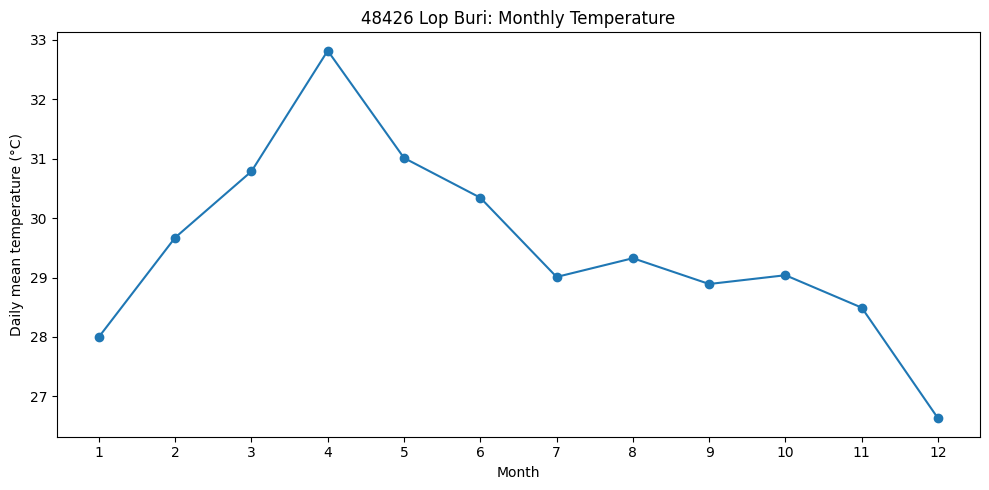

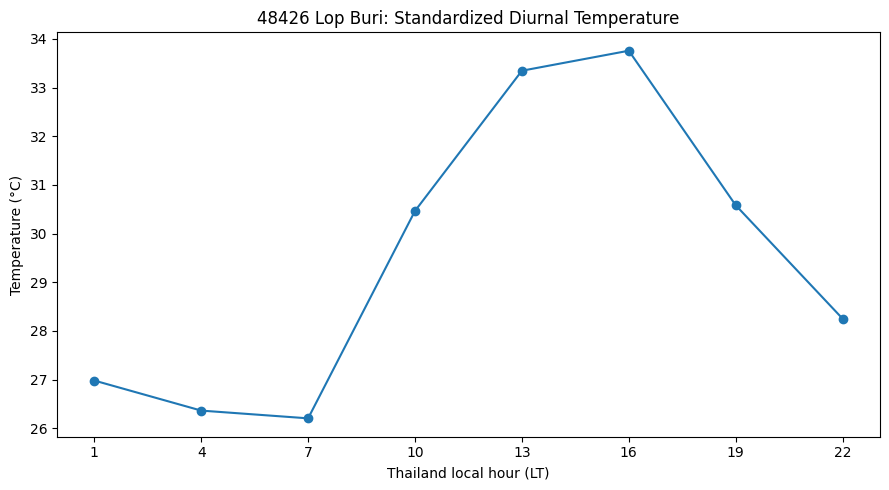

 n_valid_days  mean_daily_T_c  median_daily_T_c  p10_daily_T_c  p90_daily_T_c  mean_observed_3h_DTR_c
          366          29.493            29.425         27.581         31.938                   8.251
season  n_days  mean_T_c  median_T_c  mean_DTR_c
   DRY     182    29.383      29.125       9.145
   WET     184    29.603      29.506       7.366
✅ Cell 19 completed.


In [ ]:


# ==============================================================================================
# COPY AS CELL 19
# ==============================================================================================
# CELL 19 — TEMPERATURE: ANNUAL, MONTHLY, DIURNAL, DRY/WET
Tday=daily_met[daily_met['temperature_QA_pass']==True].copy()
summary=pd.DataFrame([{'n_valid_days':len(Tday),'mean_daily_T_c':Tday['temperature_mean_c'].mean(),
                       'median_daily_T_c':Tday['temperature_mean_c'].median(),'p10_daily_T_c':Tday['temperature_mean_c'].quantile(.1),
                       'p90_daily_T_c':Tday['temperature_mean_c'].quantile(.9),'mean_observed_3h_DTR_c':Tday['dtr_observed_3h_c'].mean()}])
summary.to_csv(TABLE_DIR/'temperature_annual_summary.csv',index=False,encoding='utf-8-sig')
monthly=Tday.groupby('month',as_index=False).agg(n_days=('date_local','size'),mean_T_c=('temperature_mean_c','mean'),median_T_c=('temperature_mean_c','median'),mean_DTR_c=('dtr_observed_3h_c','mean'))
monthly.to_csv(TABLE_DIR/'temperature_monthly_summary.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(10,5)); ax.plot(monthly['month'],monthly['mean_T_c'],marker='o'); ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Daily mean temperature (°C)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Monthly Temperature'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig18_monthly_temperature.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

Tflags=daily_met[['date_local','temperature_QA_pass']]
Tstd=met_std.merge(Tflags,on='date_local',how='left',validate='many_to_one')
di=[]
for h in CORE_SYNOP_HOURS_LOCAL:
    g=Tstd[(Tstd['hour_local']==h)&(Tstd['temperature_QA_pass']==True)]
    di.append({'hour_local':h,'mean_T_c':g['t2m'].mean(),'median_T_c':g['t2m'].median(),'n':g['t2m'].notna().sum()})
Tdi=pd.DataFrame(di); Tdi.to_csv(TABLE_DIR/'temperature_diurnal_cycle.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(Tdi['hour_local'],Tdi['mean_T_c'],marker='o'); ax.set_xticks(CORE_SYNOP_HOURS_LOCAL); ax.set_xlabel('Thailand local hour (LT)'); ax.set_ylabel('Temperature (°C)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Standardized Diurnal Temperature'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig19_diurnal_temperature.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
season=Tday.groupby('season',as_index=False).agg(n_days=('date_local','size'),mean_T_c=('temperature_mean_c','mean'),median_T_c=('temperature_mean_c','median'),mean_DTR_c=('dtr_observed_3h_c','mean'))
season.to_csv(TABLE_DIR/'temperature_dry_wet_summary.csv',index=False,encoding='utf-8-sig')
print(summary.round(3).to_string(index=False)); print(season.round(3).to_string(index=False)); print('✅ Cell 19 completed.')

## วิเคราะห์ความชื้น

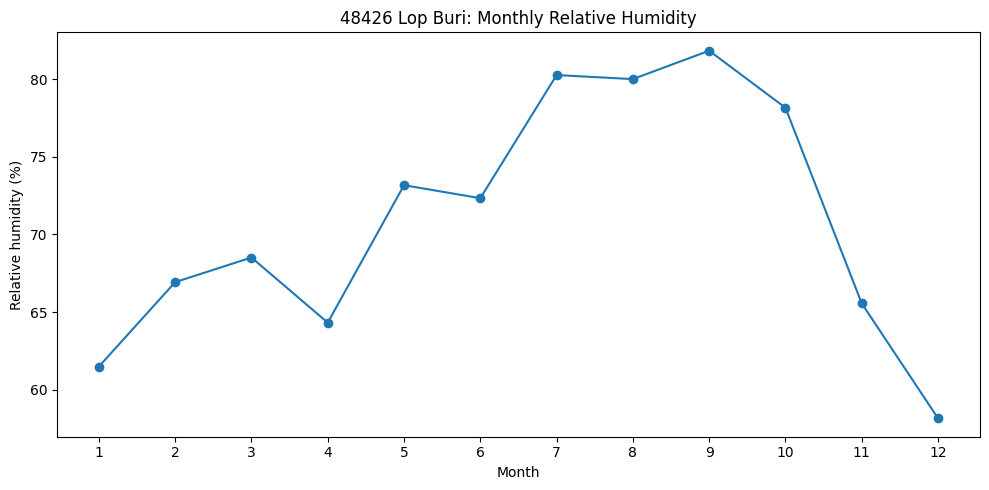

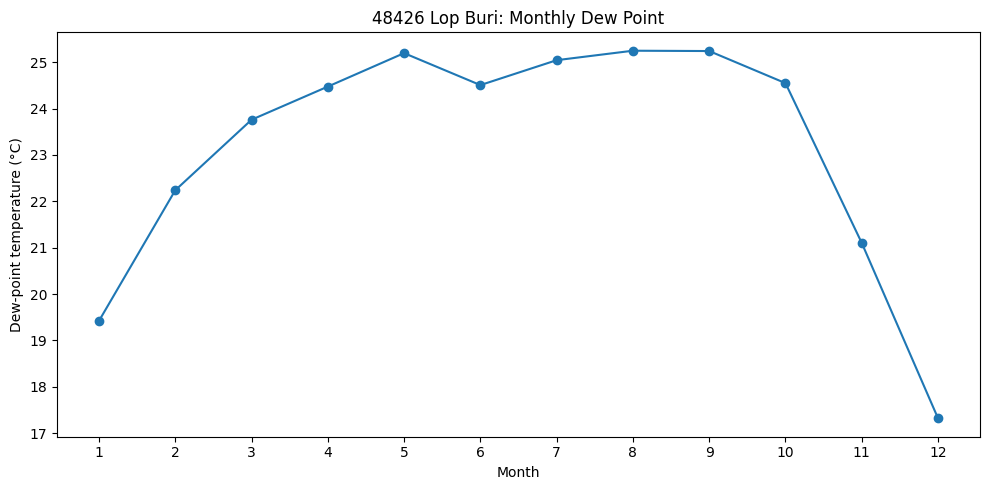

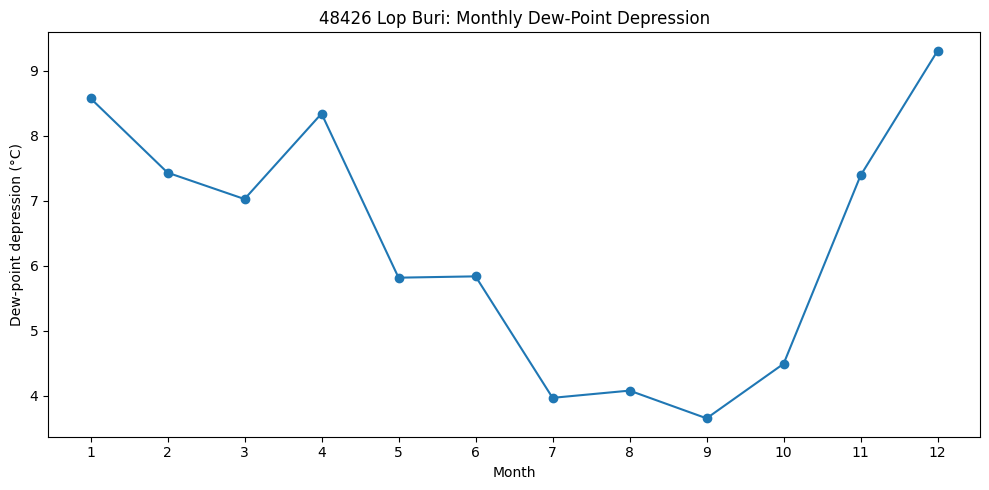

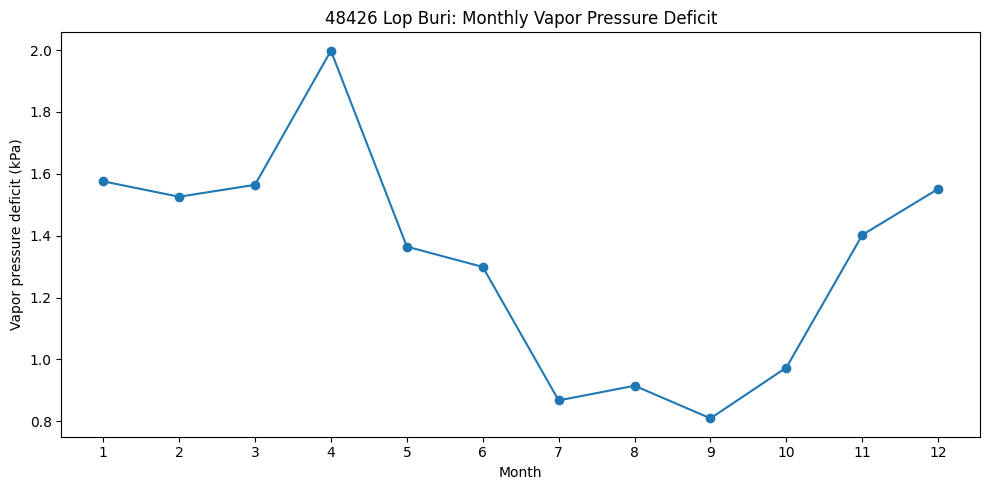

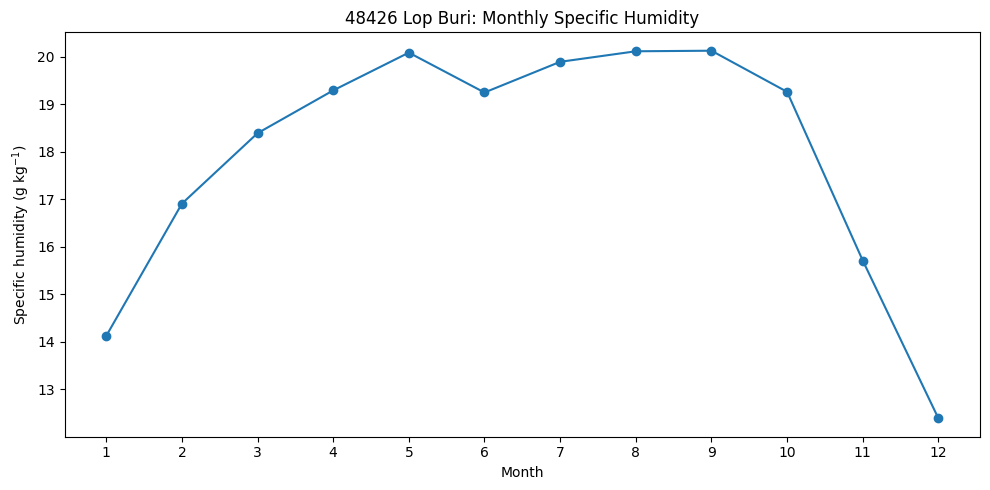

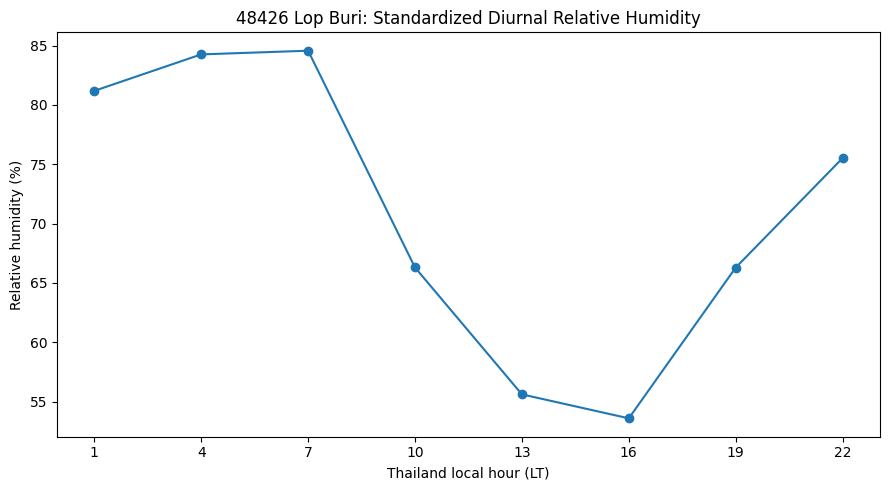

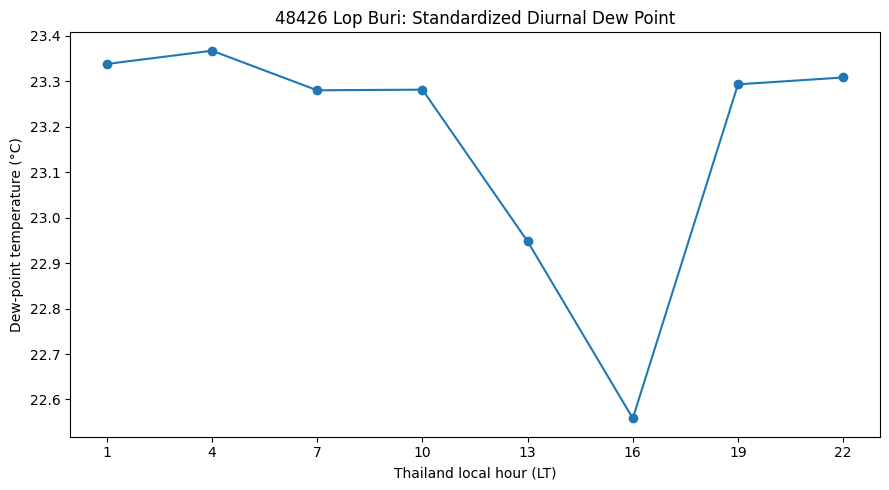

season  mean_RH_pct  mean_Td_c  mean_DPD_c  mean_VPD_kpa  mean_q_gkg
   DRY       64.123     21.361       8.022         1.603      16.112
   WET       77.629     24.965       4.638         1.038      19.786
✅ Cell 20 completed.


In [ ]:



# ==============================================================================================
# COPY AS CELL 20
# ==============================================================================================
# CELL 20 — MOISTURE: RH, DEW POINT, DPD, VPD, SPECIFIC HUMIDITY
Mday=daily_met[(daily_met['rh_QA_pass']==True)|(daily_met['dewpoint_QA_pass']==True)].copy()
monthly=[]
for m in range(1,13):
    g=Mday[Mday['month']==m]
    monthly.append({'month':m,'mean_RH_pct':g.loc[g['rh_QA_pass'],'rh_mean_pct'].mean(),
                    'mean_Td_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_mean_c'].mean(),
                    'mean_DPD_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_depression_mean_c'].mean(),
                    'mean_VPD_kpa':g.loc[g['dewpoint_QA_pass'],'vpd_mean_kpa'].mean(),
                    'mean_q_gkg':g.loc[g['dewpoint_QA_pass'],'specific_humidity_mean_gkg'].mean()})
Mmonth=pd.DataFrame(monthly); Mmonth.to_csv(TABLE_DIR/'moisture_monthly_summary.csv',index=False,encoding='utf-8-sig')
for col,ylabel,title,fname in [('mean_RH_pct','Relative humidity (%)','Monthly Relative Humidity','Fig20_monthly_RH.png'),
                               ('mean_Td_c','Dew-point temperature (°C)','Monthly Dew Point','Fig21_monthly_dewpoint.png'),
                               ('mean_DPD_c','Dew-point depression (°C)','Monthly Dew-Point Depression','Fig22_monthly_DPD.png'),
                               ('mean_VPD_kpa','Vapor pressure deficit (kPa)','Monthly Vapor Pressure Deficit','Fig23_monthly_VPD.png'),
                               ('mean_q_gkg','Specific humidity (g kg$^{-1}$)','Monthly Specific Humidity','Fig24_monthly_specific_humidity.png')]:
    fig,ax=plt.subplots(figsize=(10,5)); ax.plot(Mmonth['month'],Mmonth[col],marker='o'); ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel(ylabel); ax.set_title(f'{STATION_WMO} {STATION_NAME}: {title}'); plt.tight_layout(); plt.savefig(FIG_DIR/fname,dpi=FIG_DPI,bbox_inches='tight'); plt.show()

Mflags=daily_met[['date_local','rh_QA_pass','dewpoint_QA_pass']]
Mstd=met_std.merge(Mflags,on='date_local',how='left',validate='many_to_one')
di=[]
for h in CORE_SYNOP_HOURS_LOCAL:
    g=Mstd[Mstd['hour_local']==h]
    di.append({'hour_local':h,'mean_RH_pct':g.loc[g['rh_QA_pass'],'rh_used_pct'].mean(),
               'mean_Td_c':g.loc[g['dewpoint_QA_pass'],'dpt2m'].mean(),
               'mean_DPD_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_depression_c'].mean(),
               'mean_VPD_kpa':g.loc[g['dewpoint_QA_pass'],'vpd_kpa'].mean(),
               'mean_q_gkg':g.loc[g['dewpoint_QA_pass'],'specific_humidity_gkg'].mean()})
Mdi=pd.DataFrame(di); Mdi.to_csv(TABLE_DIR/'moisture_diurnal_cycle.csv',index=False,encoding='utf-8-sig')
for col,ylabel,title,fname in [('mean_RH_pct','Relative humidity (%)','Diurnal Relative Humidity','Fig25_diurnal_RH.png'),('mean_Td_c','Dew-point temperature (°C)','Diurnal Dew Point','Fig26_diurnal_dewpoint.png')]:
    fig,ax=plt.subplots(figsize=(9,5)); ax.plot(Mdi['hour_local'],Mdi[col],marker='o'); ax.set_xticks(CORE_SYNOP_HOURS_LOCAL); ax.set_xlabel('Thailand local hour (LT)'); ax.set_ylabel(ylabel); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Standardized {title}'); plt.tight_layout(); plt.savefig(FIG_DIR/fname,dpi=FIG_DPI,bbox_inches='tight'); plt.show()
season=[]
for s in ['DRY','WET']:
    g=Mday[Mday['season']==s]
    season.append({'season':s,'mean_RH_pct':g.loc[g['rh_QA_pass'],'rh_mean_pct'].mean(),'mean_Td_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_mean_c'].mean(),
                   'mean_DPD_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_depression_mean_c'].mean(),'mean_VPD_kpa':g.loc[g['dewpoint_QA_pass'],'vpd_mean_kpa'].mean(),
                   'mean_q_gkg':g.loc[g['dewpoint_QA_pass'],'specific_humidity_mean_gkg'].mean()})
Mseason=pd.DataFrame(season); Mseason.to_csv(TABLE_DIR/'moisture_dry_wet_summary.csv',index=False,encoding='utf-8-sig')
print(Mseason.round(3).to_string(index=False)); print('✅ Cell 20 completed.')



## วิเคราะห์ความกดอากาศ

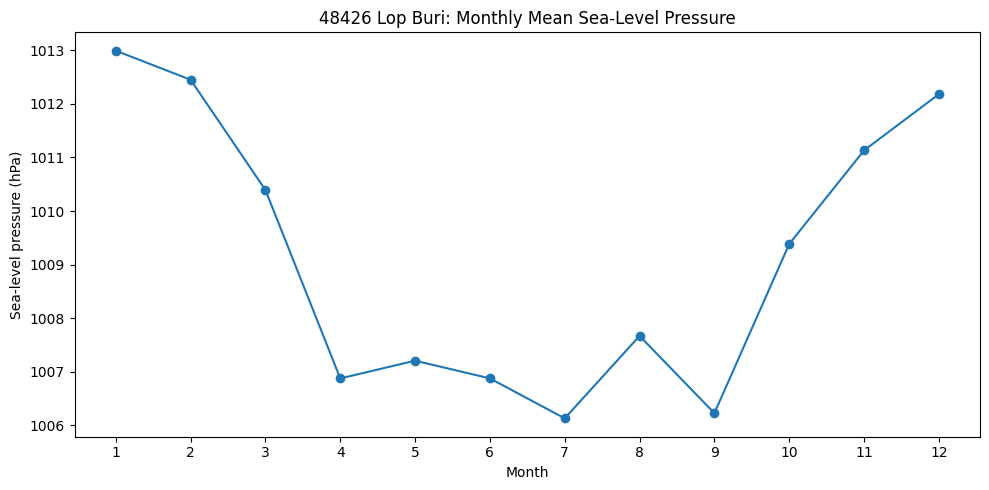

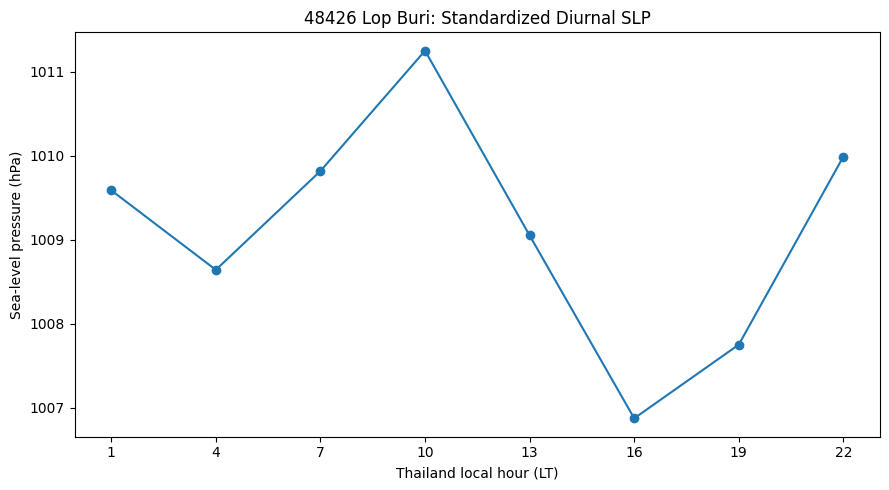

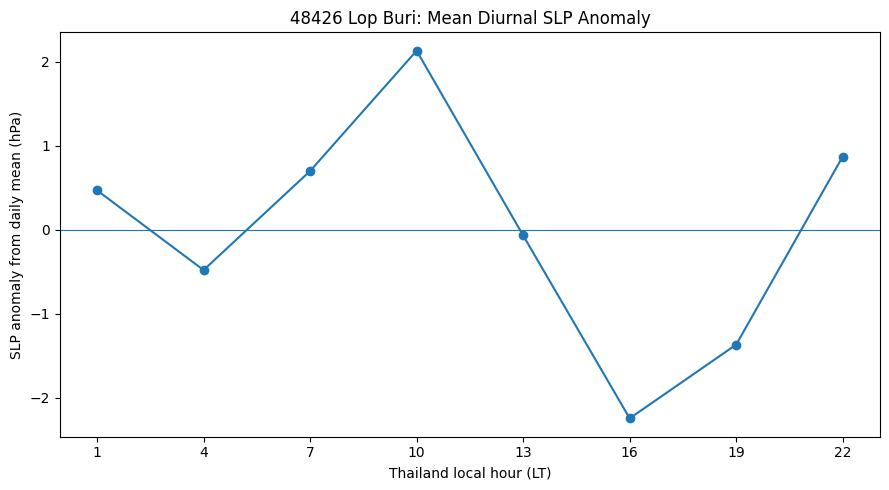

Use the anomaly curve as an atmospheric-tide diagnostic only if a coherent two-maxima/two-minima structure is evident.
✅ Cell 21 completed.


In [ ]:

# ==============================================================================================
# COPY AS CELL 21
# ==============================================================================================
# CELL 21 — PRESSURE: MONTHLY, DIURNAL, AND SEMIDIURNAL-TIDE DIAGNOSTIC
Pday=daily_met[daily_met['slp_QA_pass']==True].copy()
Pmonth=Pday.groupby('month',as_index=False).agg(n_days=('date_local','size'),mean_SLP_hpa=('slp_mean_hpa','mean'))
Pmonth.to_csv(TABLE_DIR/'pressure_monthly_summary.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(10,5)); ax.plot(Pmonth['month'],Pmonth['mean_SLP_hpa'],marker='o'); ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Sea-level pressure (hPa)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Monthly Mean Sea-Level Pressure'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig27_monthly_SLP.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

Pflags=daily_met[['date_local','slp_QA_pass']]
Pstd=met_std.merge(Pflags,on='date_local',how='left',validate='many_to_one'); Pstd=Pstd[Pstd['slp_QA_pass']==True].copy()
Pstd['daily_mean_SLP']=Pstd.groupby('date_local')['slp'].transform('mean'); Pstd['SLP_anomaly_hpa']=Pstd['slp']-Pstd['daily_mean_SLP']
di=[]
for h in CORE_SYNOP_HOURS_LOCAL:
    g=Pstd[Pstd['hour_local']==h]
    di.append({'hour_local':h,'mean_SLP_hpa':g['slp'].mean(),'mean_SLP_anomaly_hpa':g['SLP_anomaly_hpa'].mean()})
Pdi=pd.DataFrame(di); Pdi.to_csv(TABLE_DIR/'pressure_diurnal_and_anomaly.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(Pdi['hour_local'],Pdi['mean_SLP_hpa'],marker='o'); ax.set_xticks(CORE_SYNOP_HOURS_LOCAL); ax.set_xlabel('Thailand local hour (LT)'); ax.set_ylabel('Sea-level pressure (hPa)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Standardized Diurnal SLP'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig28_diurnal_SLP.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(Pdi['hour_local'],Pdi['mean_SLP_anomaly_hpa'],marker='o'); ax.axhline(0,linewidth=.8); ax.set_xticks(CORE_SYNOP_HOURS_LOCAL); ax.set_xlabel('Thailand local hour (LT)'); ax.set_ylabel('SLP anomaly from daily mean (hPa)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Mean Diurnal SLP Anomaly'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig29_diurnal_SLP_anomaly.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
print('Use the anomaly curve as an atmospheric-tide diagnostic only if a coherent two-maxima/two-minima structure is evident.'); print('✅ Cell 21 completed.')

## วิเคราะห์เมฆ

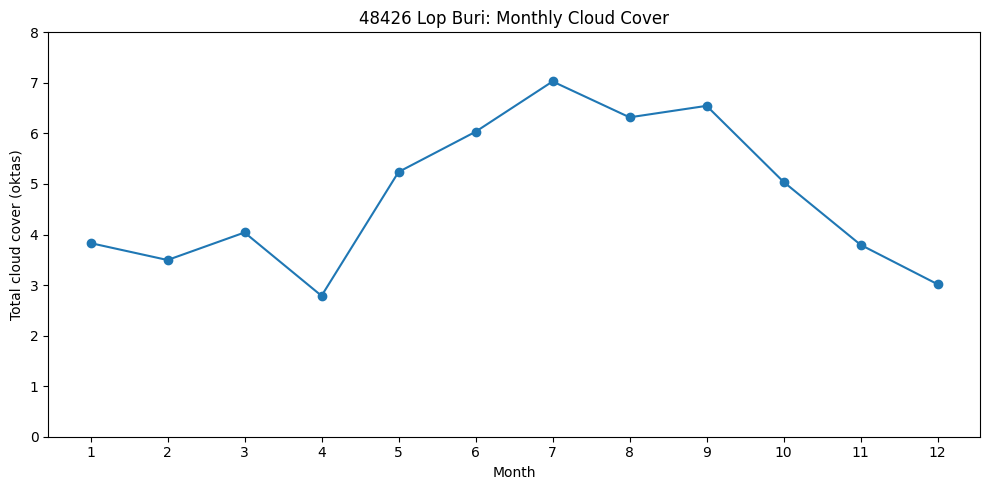

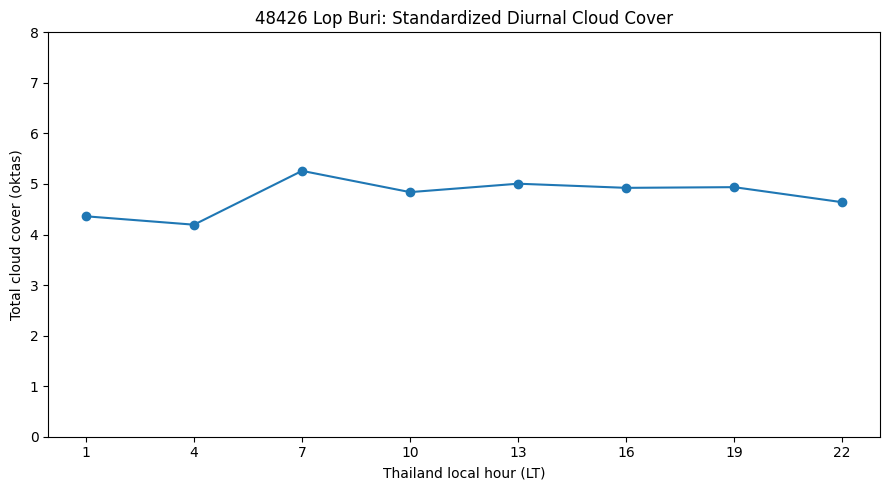

 n_standardized_rows  n_okta_0_8  n_code9_obscured  min_okta  max_okta
                2927        2927                 0       0.0       8.0
✅ Cell 22 completed.


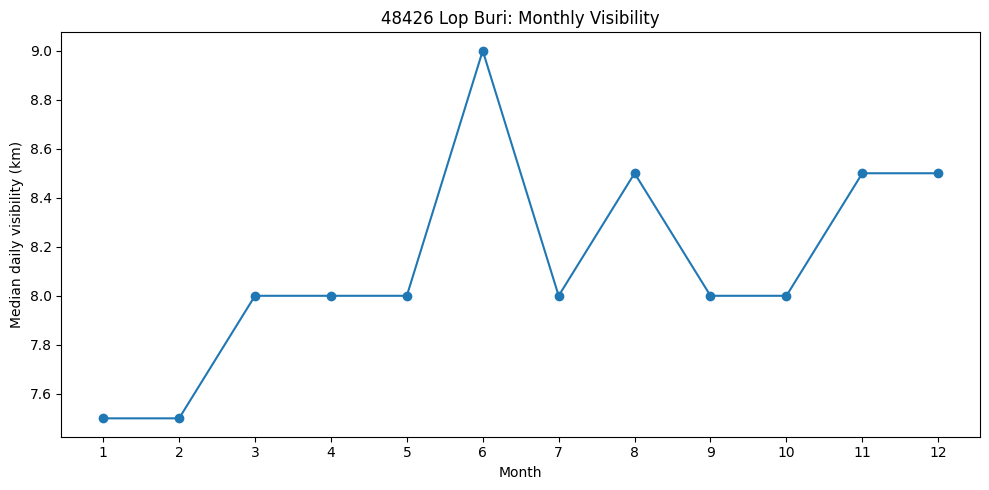

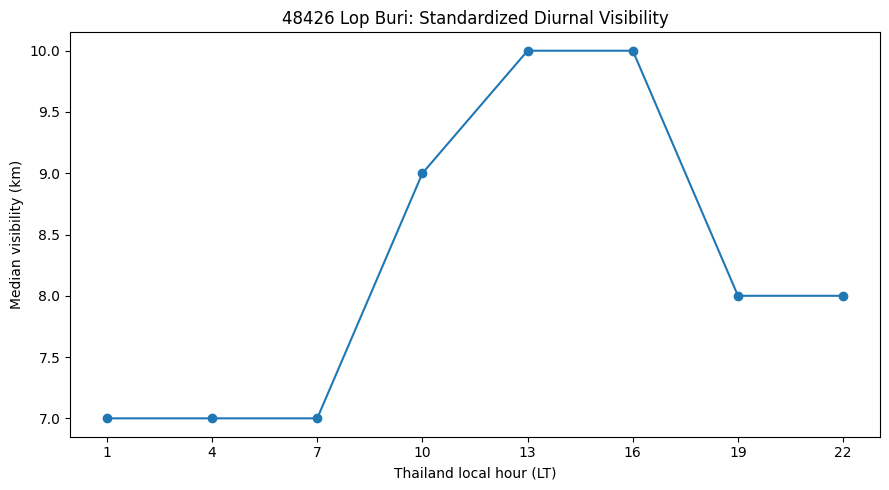

input_unit_setting  n_valid  min_km  median_km  p90_km  max_km
                 m     2927     3.0        8.0    10.0    15.0
Low visibility is not attributed to a cause in this notebook.
✅ Cell 23 completed.
 duration_hours  end_hour_local  n_reports  nonzero_reports  mean_amount_mm  max_amount_mm
           12.0              13        366               19           0.348           51.0
           12.0               7        333                0           0.000            0.0
           12.0              19        316                0           0.000            0.0
           12.0               1        299                0           0.000            0.0
           18.0              19         50               42           6.906           53.0
            3.0              22         14               14           8.150           41.0
            3.0              16          5                3           1.240            4.0
            3.0               7          4                2    

In [ ]:



# ==============================================================================================
# COPY AS CELL 22
# ==============================================================================================
# CELL 22 — CLOUD COVER: CODE AUDIT, MONTHLY, DIURNAL
cloud_audit=pd.DataFrame([{'n_standardized_rows':len(met_std),'n_okta_0_8':int(met_std['cloud_okta'].notna().sum()),
                           'n_code9_obscured':int(met_std['cloud_obscured_code9'].sum()),'min_okta':met_std['cloud_okta'].min(),'max_okta':met_std['cloud_okta'].max()}])
cloud_audit.to_csv(QA_DIR/'06_cloud_code_audit.csv',index=False,encoding='utf-8-sig')
Cflags=daily_met[['date_local','cloud_QA_pass']]
Cstd=met_std.merge(Cflags,on='date_local',how='left',validate='many_to_one')
Cmonth=[]
for m in range(1,13):
    g=Cstd[(Cstd['month']==m)&(Cstd['cloud_QA_pass']==True)]
    Cmonth.append({'month':m,'n_valid':g['cloud_okta'].notna().sum(),'mean_cloud_okta':g['cloud_okta'].mean(),'median_cloud_okta':g['cloud_okta'].median()})
Cmonth=pd.DataFrame(Cmonth); Cmonth.to_csv(TABLE_DIR/'cloud_monthly_summary.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(10,5)); ax.plot(Cmonth['month'],Cmonth['mean_cloud_okta'],marker='o'); ax.set_xticks(range(1,13)); ax.set_ylim(0,8); ax.set_xlabel('Month'); ax.set_ylabel('Total cloud cover (oktas)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Monthly Cloud Cover'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig30_monthly_cloud.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
Cdi=[]
for h in CORE_SYNOP_HOURS_LOCAL:
    g=Cstd[(Cstd['hour_local']==h)&(Cstd['cloud_QA_pass']==True)]
    Cdi.append({'hour_local':h,'mean_cloud_okta':g['cloud_okta'].mean(),'n_valid':g['cloud_okta'].notna().sum()})
Cdi=pd.DataFrame(Cdi); Cdi.to_csv(TABLE_DIR/'cloud_diurnal_cycle.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(Cdi['hour_local'],Cdi['mean_cloud_okta'],marker='o'); ax.set_xticks(CORE_SYNOP_HOURS_LOCAL); ax.set_ylim(0,8); ax.set_xlabel('Thailand local hour (LT)'); ax.set_ylabel('Total cloud cover (oktas)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Standardized Diurnal Cloud Cover'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig31_diurnal_cloud.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
print(cloud_audit.to_string(index=False)); print('✅ Cell 22 completed.')


# ==============================================================================================
# COPY AS CELL 23
# ==============================================================================================
# CELL 23 — VISIBILITY: UNIT/RANGE AUDIT, MONTHLY, DIURNAL, LOW-VISIBILITY FREQUENCY
x=met_std['visibility_km'].dropna()
vis_audit=pd.DataFrame([{'input_unit_setting':VISIBILITY_INPUT_UNIT,'n_valid':len(x),'min_km':x.min(),'median_km':x.median(),'p90_km':x.quantile(.9),'max_km':x.max()}])
vis_audit.to_csv(QA_DIR/'07_visibility_unit_range_audit.csv',index=False,encoding='utf-8-sig')
Vday=daily_met[daily_met['visibility_QA_pass']==True].copy()
Vmonth=Vday.groupby('month',as_index=False).agg(n_days=('date_local','size'),median_visibility_km=('visibility_median_km','median'),p10_visibility_km=('visibility_median_km',lambda s:s.quantile(.1)))
Vmonth.to_csv(TABLE_DIR/'visibility_monthly_summary.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(10,5)); ax.plot(Vmonth['month'],Vmonth['median_visibility_km'],marker='o'); ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Median daily visibility (km)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Monthly Visibility'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig32_monthly_visibility.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
Vflags=daily_met[['date_local','visibility_QA_pass']]
Vstd=met_std.merge(Vflags,on='date_local',how='left',validate='many_to_one')
Vdi=[]
for h in CORE_SYNOP_HOURS_LOCAL:
    g=Vstd[(Vstd['hour_local']==h)&(Vstd['visibility_QA_pass']==True)]; vals=g['visibility_km'].dropna()
    Vdi.append({'hour_local':h,'median_visibility_km':vals.median(),'percent_below_10km':100*(vals<10).mean() if len(vals) else np.nan,'percent_below_5km':100*(vals<5).mean() if len(vals) else np.nan})
Vdi=pd.DataFrame(Vdi); Vdi.to_csv(TABLE_DIR/'visibility_diurnal_low_visibility.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(Vdi['hour_local'],Vdi['median_visibility_km'],marker='o'); ax.set_xticks(CORE_SYNOP_HOURS_LOCAL); ax.set_xlabel('Thailand local hour (LT)'); ax.set_ylabel('Median visibility (km)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Standardized Diurnal Visibility'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig33_diurnal_visibility.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
print(vis_audit.round(3).to_string(index=False)); print('Low visibility is not attributed to a cause in this notebook.'); print('✅ Cell 23 completed.')


# ==============================================================================================
# COPY AS CELL 24
# ==============================================================================================
# CELL 24 — PRECIPITATION-INTERVAL AUDIT AND FIXED-SCHEME COVERAGE
rain=precip_intervals.copy()
if rain.empty:
    rain_audit=pd.DataFrame(); fixed_scheme=pd.DataFrame(); print('No precipitation-interval archive available.')
else:
    rain['precipitation_amount']=pd.to_numeric(rain['precipitation_amount'],errors='coerce')
    rain['precipitation_time']=pd.to_numeric(rain['precipitation_time'],errors='coerce')
    if 'accumulation_start_local' not in rain.columns and 'accumulation_start_utc' in rain.columns: rain['accumulation_start_local']=rain['accumulation_start_utc'].dt.tz_convert(LOCAL_TZ)
    if 'accumulation_end_local' not in rain.columns and 'accumulation_end_utc' in rain.columns: rain['accumulation_end_local']=rain['accumulation_end_utc'].dt.tz_convert(LOCAL_TZ)
    rain=rain[rain['precipitation_amount'].notna()&rain['precipitation_time'].notna()&(rain['precipitation_time']>0)&(rain['precipitation_time']<=24)].copy()
    rain['end_hour_local']=rain['accumulation_end_local'].dt.hour
    rain=rain[rain['accumulation_end_local'].dt.tz_localize(None).dt.normalize().between(pd.Timestamp(ANALYSIS_START_DATE),pd.Timestamp(ANALYSIS_END_DATE))]
    rain=rain.drop_duplicates(['accumulation_start_local','accumulation_end_local','precipitation_amount'],keep='last')
    rows=[]
    for (dur,h),g in rain.groupby(['precipitation_time','end_hour_local'],sort=True):
        rows.append({'duration_hours':dur,'end_hour_local':int(h),'n_reports':len(g),'nonzero_reports':int((g['precipitation_amount']>0).sum()),'mean_amount_mm':g['precipitation_amount'].mean(),'max_amount_mm':g['precipitation_amount'].max()})
    rain_audit=pd.DataFrame(rows).sort_values(['n_reports'],ascending=False)
    ncal=(pd.Timestamp(ANALYSIS_END_DATE)-pd.Timestamp(ANALYSIS_START_DATE)).days+1
    rows=[]
    for (dur,h),g in rain.groupby(['precipitation_time','end_hour_local'],sort=True):
        nd=g['accumulation_end_local'].dt.tz_localize(None).dt.normalize().nunique()
        rows.append({'duration_hours':dur,'end_hour_local':int(h),'n_reports':len(g),'n_unique_end_dates':nd,'coverage_fraction_calendar_days':nd/ncal})
    fixed_scheme=pd.DataFrame(rows).sort_values(['coverage_fraction_calendar_days','n_reports'],ascending=[False,False])
rain_audit.to_csv(QA_DIR/'08_precipitation_interval_audit.csv',index=False,encoding='utf-8-sig')
fixed_scheme.to_csv(QA_DIR/'09_precipitation_fixed_scheme_coverage.csv',index=False,encoding='utf-8-sig')
print(rain_audit.head(30).round(3).to_string(index=False) if len(rain_audit) else 'No rain audit rows')
print('\nFIXED SCHEMES'); print(fixed_scheme.head(30).round(3).to_string(index=False) if len(fixed_scheme) else 'No fixed schemes')
print('Do not sum overlapping precipitation reports.'); print('✅ Cell 24 completed.')


# ==============================================================================================
# COPY AS CELL 25
# ==============================================================================================
# CELL 25 — EXACT LOCAL-CALENDAR DAILY RAINFALL RECONSTRUCTION ATTEMPT

def cover_path(intervals,day_start,day_end,maximize=True):
    c=intervals[(intervals['accumulation_start_local']>=day_start)&(intervals['accumulation_end_local']<=day_end)].copy()
    sm={}
    for idx,row in c.iterrows(): sm.setdefault(row['accumulation_start_local'],[]).append(idx)
    memo={}
    def solve(cur):
        if cur==day_end: return []
        if cur in memo: return memo[cur]
        opts=[]
        for idx in sm.get(cur,[]):
            end=c.loc[idx,'accumulation_end_local']
            if end<=cur: continue
            tail=solve(end)
            if tail is not None: opts.append([idx]+tail)
        if not opts: memo[cur]=None; return None
        best=max(opts,key=len) if maximize else min(opts,key=len); memo[cur]=best; return best
    return solve(day_start)

rows=[]
if not rain.empty:
    for d in pd.date_range(ANALYSIS_START_DATE,ANALYSIS_END_DATE,freq='D'):
        ds=pd.Timestamp(d,tz=LOCAL_TZ); de=ds+pd.Timedelta(days=1)
        pmax=cover_path(rain,ds,de,True); pmin=cover_path(rain,ds,de,False)
        if pmax is None:
            rows.append({'date_local':pd.Timestamp(d),'daily_rainfall_mm':np.nan,'rainfall_QA_status':'NO_EXACT_LOCAL_DAY_COVERAGE','alternative_total_difference_mm':np.nan})
            continue
        tmax=rain.loc[pmax,'precipitation_amount'].sum(); tmin=rain.loc[pmin,'precipitation_amount'].sum(); diff=abs(tmax-tmin)
        if pmax!=pmin and diff<=RAIN_MULTIPATH_TOLERANCE_MM: status='EXACT_COMPLETE_CONSISTENT_MULTIPATH'; value=(tmax+tmin)/2
        elif pmax!=pmin and diff>RAIN_MULTIPATH_TOLERANCE_MM: status='EXACT_COMPLETE_CONFLICTING_PATHS'; value=np.nan
        else: status='EXACT_COMPLETE_SINGLE_PATH'; value=tmax
        rows.append({'date_local':pd.Timestamp(d),'daily_rainfall_mm':value,'rainfall_QA_status':status,'alternative_total_difference_mm':diff})
rain_daily=pd.DataFrame(rows)
rain_daily.to_csv(TABLE_DIR/'rainfall_exact_local_day_reconstruction.csv',index=False,encoding='utf-8-sig')
if len(rain_daily):
    print(rain_daily['rainfall_QA_status'].value_counts().to_string())
    valid=rain_daily['rainfall_QA_status'].isin(['EXACT_COMPLETE_CONSISTENT_MULTIPATH','EXACT_COMPLETE_SINGLE_PATH'])
    coverage=valid.mean(); print('Valid exact local-day rainfall coverage:',round(float(coverage),3))
    if coverage>=.75:
        r=rain_daily[valid].copy(); r['month']=r['date_local'].dt.month; monthly=r.groupby('month',as_index=False)['daily_rainfall_mm'].sum()
        monthly.to_csv(TABLE_DIR/'monthly_rainfall_QA_valid.csv',index=False,encoding='utf-8-sig')
        fig,ax=plt.subplots(figsize=(10,5)); ax.bar(monthly['month'],monthly['daily_rainfall_mm']); ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Rainfall total (mm)'); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Monthly Rainfall from Exact Local-Day Coverage'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig34_monthly_rainfall_QA_valid.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
    else:
        print('Coverage <75%: no monthly daily-rainfall figure is accepted. Use a separate validated rainfall source or fixed accumulation scheme.')
else:
    print('No rainfall reconstruction table generated.')
print('✅ Cell 25 completed.')


# ==============================================================================================
# COPY AS CELL 26
# ==============================================================================================
# CELL 26 — INTEGRATED MONTHLY AND DRY/WET METEOROLOGICAL TABLES
month=[]
for m in range(1,13):
    g=daily_met[daily_met['month']==m]
    month.append({'month':m,
                  'T_mean_c':g.loc[g['temperature_QA_pass'],'temperature_mean_c'].mean(),
                  'RH_mean_pct':g.loc[g['rh_QA_pass'],'rh_mean_pct'].mean(),
                  'Td_mean_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_mean_c'].mean(),
                  'VPD_mean_kpa':g.loc[g['dewpoint_QA_pass'],'vpd_mean_kpa'].mean(),
                  'q_mean_gkg':g.loc[g['dewpoint_QA_pass'],'specific_humidity_mean_gkg'].mean(),
                  'WS_mean_ms':g.loc[g['wind_QA_pass'],'wind_speed_scalar_mean_ms'].mean(),
                  'SLP_mean_hpa':g.loc[g['slp_QA_pass'],'slp_mean_hpa'].mean(),
                  'cloud_mean_okta':g.loc[g['cloud_QA_pass'],'cloud_mean_okta'].mean(),
                  'visibility_median_km':g.loc[g['visibility_QA_pass'],'visibility_median_km'].median()})
monthly_met=pd.DataFrame(month); monthly_met.to_csv(TABLE_DIR/'integrated_monthly_meteorology.csv',index=False,encoding='utf-8-sig')
season=[]
for s in ['DRY','WET']:
    g=daily_met[daily_met['season']==s]
    season.append({'season':s,'n_days':len(g),
                   'T_mean_c':g.loc[g['temperature_QA_pass'],'temperature_mean_c'].mean(),
                   'RH_mean_pct':g.loc[g['rh_QA_pass'],'rh_mean_pct'].mean(),
                   'Td_mean_c':g.loc[g['dewpoint_QA_pass'],'dewpoint_mean_c'].mean(),
                   'VPD_mean_kpa':g.loc[g['dewpoint_QA_pass'],'vpd_mean_kpa'].mean(),
                   'q_mean_gkg':g.loc[g['dewpoint_QA_pass'],'specific_humidity_mean_gkg'].mean(),
                   'WS_mean_ms':g.loc[g['wind_QA_pass'],'wind_speed_scalar_mean_ms'].mean(),
                   'SLP_mean_hpa':g.loc[g['slp_QA_pass'],'slp_mean_hpa'].mean(),
                   'cloud_mean_okta':g.loc[g['cloud_QA_pass'],'cloud_mean_okta'].mean(),
                   'visibility_median_km':g.loc[g['visibility_QA_pass'],'visibility_median_km'].median()})
seasonal_met=pd.DataFrame(season); seasonal_met.to_csv(TABLE_DIR/'integrated_dry_wet_meteorology.csv',index=False,encoding='utf-8-sig')
print(monthly_met.round(3).to_string(index=False)); print('\nDRY/WET'); print(seasonal_met.round(3).to_string(index=False)); print('✅ Cell 26 completed.')


# ==============================================================================================
# COPY AS CELL 27
# ==============================================================================================
# CELL 27 — STANDARDIZED DIURNAL MULTIVARIABLE TABLE
rows=[]
for h in CORE_SYNOP_HOURS_LOCAL:
    g=met_std[met_std['hour_local']==h]
    rows.append({'hour_local':h,'T_mean_c':g['t2m'].mean(),'RH_mean_pct':g['rh_used_pct'].mean(),'Td_mean_c':g['dpt2m'].mean(),
                 'VPD_mean_kpa':g['vpd_kpa'].mean(),'q_mean_gkg':g['specific_humidity_gkg'].mean(),
                 'WS_mean_ms':g['wind_speed_ms'].mean(),'SLP_mean_hpa':g['slp'].mean(),'cloud_mean_okta':g['cloud_okta'].mean(),
                 'visibility_median_km':g['visibility_km'].median()})
diurnal_met=pd.DataFrame(rows); diurnal_met.to_csv(TABLE_DIR/'integrated_standardized_diurnal_meteorology.csv',index=False,encoding='utf-8-sig')
print(diurnal_met.round(3).to_string(index=False)); print('✅ Cell 27 completed.')



## สถิติ

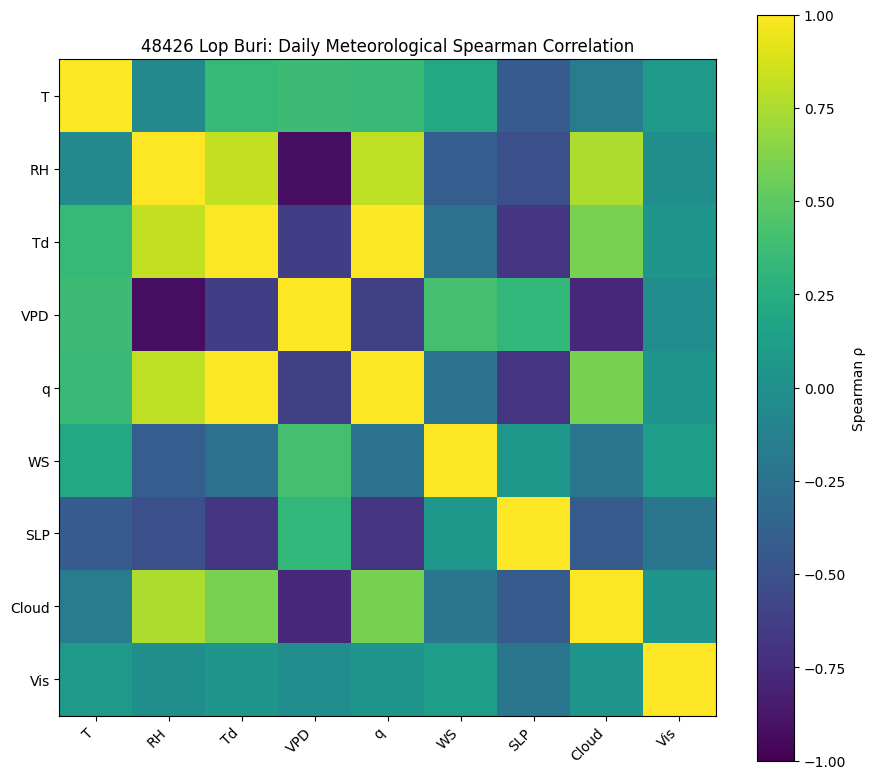

                            temperature_mean_c  rh_mean_pct  dewpoint_mean_c  vpd_mean_kpa  specific_humidity_mean_gkg  wind_speed_scalar_mean_ms  slp_mean_hpa  cloud_mean_okta  visibility_median_km
temperature_mean_c                       1.000       -0.061            0.340         0.375                       0.346                      0.210        -0.417           -0.163                 0.072
rh_mean_pct                             -0.061        1.000            0.817        -0.927                       0.810                     -0.405        -0.513            0.753                -0.006
dewpoint_mean_c                          0.340        0.817            1.000        -0.628                       0.999                     -0.248        -0.682            0.596                 0.050
vpd_mean_kpa                             0.375       -0.927           -0.628         1.000                      -0.618                      0.413         0.325           -0.771                -0.020
speci

In [ ]:

# ==============================================================================================
# COPY AS CELL 28
# ==============================================================================================
# CELL 28 — DAILY SPEARMAN METEOROLOGICAL CORRELATION MATRIX
cols=['temperature_mean_c','rh_mean_pct','dewpoint_mean_c','vpd_mean_kpa','specific_humidity_mean_gkg','wind_speed_scalar_mean_ms','slp_mean_hpa','cloud_mean_okta','visibility_median_km']
cols=[c for c in cols if c in daily_met.columns and daily_met[c].notna().sum()>=10]
corr=daily_met[cols].corr(method='spearman'); corr.to_csv(TABLE_DIR/'daily_meteorological_spearman_correlation.csv',encoding='utf-8-sig')
label_map={'temperature_mean_c':'T','rh_mean_pct':'RH','dewpoint_mean_c':'Td','vpd_mean_kpa':'VPD','specific_humidity_mean_gkg':'q','wind_speed_scalar_mean_ms':'WS','slp_mean_hpa':'SLP','cloud_mean_okta':'Cloud','visibility_median_km':'Vis'}
labels=[label_map[c] for c in cols]
fig,ax=plt.subplots(figsize=(9,8)); im=ax.imshow(corr.values,vmin=-1,vmax=1); ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols))); ax.set_xticklabels(labels,rotation=45,ha='right'); ax.set_yticklabels(labels); ax.set_title(f'{STATION_WMO} {STATION_NAME}: Daily Meteorological Spearman Correlation'); cb=fig.colorbar(im,ax=ax); cb.set_label('Spearman ρ'); plt.tight_layout(); plt.savefig(FIG_DIR/'Fig35_meteorological_spearman_correlation.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()
print(corr.round(3).to_string()); print('Descriptive association only; no causal interpretation.'); print('✅ Cell 28 completed.')


# ==============================================================================================
# COPY AS CELL 29
# ==============================================================================================
# CELL 29 — ANNUAL SUMMARY, OUTPUT INVENTORY, FINAL INTEGRITY REPORT
summary=[]
def add(name,unit,series,flag):
    x=series.dropna(); summary.append({'variable':name,'unit':unit,'n_valid_days':int(flag.sum()),'mean':x.mean() if len(x) else np.nan,'median':x.median() if len(x) else np.nan,'p10':x.quantile(.1) if len(x) else np.nan,'p90':x.quantile(.9) if len(x) else np.nan})
add('Temperature','°C',daily_met['temperature_mean_c'],daily_met['temperature_QA_pass'])
add('Relative humidity','%',daily_met['rh_mean_pct'],daily_met['rh_QA_pass'])
add('Dew point','°C',daily_met['dewpoint_mean_c'],daily_met['dewpoint_QA_pass'])
add('VPD','kPa',daily_met['vpd_mean_kpa'],daily_met['dewpoint_QA_pass'])
add('Specific humidity','g kg-1',daily_met['specific_humidity_mean_gkg'],daily_met['dewpoint_QA_pass'])
add('Wind speed','m s-1',daily_met['wind_speed_scalar_mean_ms'],daily_met['wind_QA_pass'])
add('Sea-level pressure','hPa',daily_met['slp_mean_hpa'],daily_met['slp_QA_pass'])
add('Cloud cover','okta',daily_met['cloud_mean_okta'],daily_met['cloud_QA_pass'])
add('Visibility','km',daily_met['visibility_median_km'],daily_met['visibility_QA_pass'])
annual=pd.DataFrame(summary); annual.to_csv(TABLE_DIR/'annual_meteorological_summary.csv',index=False,encoding='utf-8-sig')

inventory=[]
for typ,d,pattern in [('FIGURE',FIG_DIR,'*.png'),('TABLE',TABLE_DIR,'*.csv'),('QA',QA_DIR,'*.csv')]:
    for p in sorted(d.glob(pattern)): inventory.append({'type':typ,'filename':p.name,'path':str(p)})
inv=pd.DataFrame(inventory); inv.to_csv(ANALYSIS_DIR/'output_inventory.csv',index=False,encoding='utf-8-sig')

assert daily_met['date_local'].is_unique
assert met_std[['date_local','hour_local']].duplicated().sum()==0
expected=(pd.Timestamp(ANALYSIS_END_DATE)-pd.Timestamp(ANALYSIS_START_DATE)).days+1
report=pd.DataFrame([{'check':'requested_calendar_days','value':expected},{'check':'standardized_QA_pass_days','value':met_std['date_local'].nunique()},{'check':'standardized_rows','value':len(met_std)},{'check':'daily_master_rows','value':len(daily_met)}])
report.to_csv(QA_DIR/'10_final_integrity_report.csv',index=False,encoding='utf-8-sig')
print('ANNUAL SUMMARY'); print(annual.round(3).to_string(index=False)); print('\nINTEGRITY'); print(report.to_string(index=False)); print('\nOutputs:',ANALYSIS_DIR); print('Rainfall remains separate unless exact local-day coverage passes QA.'); print('No PM2.5 data were used.'); print('✅ Cell 29 completed successfully.')